In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
LAYERS = [
    "conv1",
    "layer1.0", "layer1.1", "layer1.2",
    "layer2.0", "layer2.1", "layer2.2", "layer2.3",
    "layer3.0", "layer3.1", "layer3.2", "layer3.3", "layer3.4", "layer3.5",
    "layer4.0", "layer4.1", "layer4.2",
    "avgpool",
]

EMERGE_METRIC = "balanced"   # "balanced" | "plain"
EMERGE_FRAC   = 0.90         # e.g. 0.90 | 0.95

# ── Choose emergence criterion + tag pre / at / post ──────────────────────────
EMERGE_CRITERION = "sharp_jump"    # "frac90" | "sharp_jump"
emerge_col = "emerge_idx_frac"   if EMERGE_CRITERION == "frac90" else "emerge_idx_jump"
layer_col  = "emerge_layer_frac" if EMERGE_CRITERION == "frac90" else "emerge_layer_jump"

# ── MCBM gamma sweep ──────────────────────────────────────────────────────────
GAMMAS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

print(f"EMERGE_METRIC    : {EMERGE_METRIC}")
print(f"EMERGE_FRAC      : {EMERGE_FRAC}")
print(f"EMERGE_CRITERION : {EMERGE_CRITERION}")
print(f"GAMMAS           : {GAMMAS}")

EMERGE_METRIC    : balanced
EMERGE_FRAC      : 0.9
EMERGE_CRITERION : sharp_jump
GAMMAS           : [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]


In [3]:
import sys
ROOT     = Path("/scratch/network/cr7998/cv_emergence_project")
CUB      = ROOT / "data" / "CUB_200_2011"
ATTR_TXT = ROOT / "data" / "attributes.txt"
MCBM_FEATS = {g: ROOT / "features" / f"resnet50_mcbm_gamma{g}" for g in GAMMAS}

assert CUB.exists(),      f"Missing CUB folder: {CUB}"
assert ATTR_TXT.exists(), f"Missing attributes.txt: {ATTR_TXT}"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

def _feats_ready(feat_dir: Path) -> bool:
    return (feat_dir / "labels_train.pt").exists() and (feat_dir / "labels_test.pt").exists()

_missing = [g for g in GAMMAS if not _feats_ready(MCBM_FEATS[g])]
if _missing:
    print(f"WARNING: Features not extracted for gammas: {_missing}")
    print("Run run_mcbm_extract_adroit.sh for missing gammas.")
    GAMMAS = [g for g in GAMMAS if g not in _missing]

if not GAMMAS:
    raise RuntimeError("No MCBM features available. Extract features first.")

for g in GAMMAS:
    print(f"  [ok]   gamma={g}: {MCBM_FEATS[g]}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[config] device : {device}")
print(f"[config] GAMMAS : {GAMMAS}")

Run run_mcbm_extract_adroit.sh for missing gammas.
  [ok]   gamma=0.0: /scratch/network/cr7998/cv_emergence_project/features/resnet50_mcbm_gamma0.0
  [ok]   gamma=0.1: /scratch/network/cr7998/cv_emergence_project/features/resnet50_mcbm_gamma0.1
  [ok]   gamma=0.5: /scratch/network/cr7998/cv_emergence_project/features/resnet50_mcbm_gamma0.5
  [ok]   gamma=1.0: /scratch/network/cr7998/cv_emergence_project/features/resnet50_mcbm_gamma1.0

[config] device : cpu
[config] GAMMAS : [0.0, 0.1, 0.5, 1.0]


In [4]:
def load_species_maps(cub_root: Path):
    classes = pd.read_csv(
        cub_root / "classes.txt",
        sep=r"\s+", header=None, names=["species_id", "class_name"], engine="python",
    )
    def pretty(name: str) -> str:
        return name.split(".", 1)[-1].replace("_", " ")
    id2name = dict(zip(classes["species_id"].astype(int), classes["class_name"].map(pretty)))
    return id2name


def load_meta(cub_root: Path) -> pd.DataFrame:
    img_species = pd.read_csv(
        cub_root / "image_class_labels.txt",
        sep=r"\s+", header=None, names=["image_id", "species_id"], engine="python",
    )
    split_df = pd.read_csv(
        cub_root / "train_test_split.txt",
        sep=r"\s+", header=None, names=["image_id", "is_train"], engine="python",
    )
    meta = img_species.merge(split_df, on="image_id")
    meta["species_name"] = meta["species_id"].map(id2name)
    return meta


def load_image_attr_labels_robust(cub_root: Path) -> pd.DataFrame:
    path = cub_root / "attributes" / "image_attribute_labels.txt"
    rows = []
    bad  = 0
    with open(path, "r") as f:
        for line in f:
            toks = line.strip().split()
            if len(toks) < 4:
                bad += 1; continue
            try:
                rows.append((int(toks[0]), int(toks[1]), int(toks[2]), int(toks[3])))
            except Exception:
                bad += 1
    df = pd.DataFrame(rows, columns=["image_id", "attr_id", "is_present", "certainty"])
    print(f"Parsed rows: {len(df)}  bad lines skipped: {bad}")
    return df


def load_attr_maps(attr_txt: Path):
    rows = []
    with open(attr_txt, "r") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            aid_str, name = line.split(" ", 1)
            rows.append((int(aid_str), name))
    df = pd.DataFrame(rows, columns=["attr_id", "attr_name"])
    return df, dict(zip(df["attr_name"], df["attr_id"])), dict(zip(df["attr_id"], df["attr_name"]))


print("Defined: load_species_maps  load_meta  load_image_attr_labels_robust  load_attr_maps")

Defined: load_species_maps  load_meta  load_image_attr_labels_robust  load_attr_maps


In [5]:
id2name       = load_species_maps(CUB)
def spname(sid: int) -> str:
    return id2name.get(int(sid), f"species_{sid}")

meta          = load_meta(CUB)
img_attr_long = load_image_attr_labels_robust(CUB)
attr_df, attr_name_to_id, attr_id_to_name = load_attr_maps(ATTR_TXT)

print(f"meta          : {len(meta)} images, {meta['species_id'].nunique()} species")
print(f"img_attr_long : {len(img_attr_long)} rows")
print(f"attr_df       : {len(attr_df)} attributes")

# sanity check
_aid = attr_name_to_id["has_primary_color::yellow"]
_lab = (
    img_attr_long[img_attr_long["attr_id"] == _aid]
    .groupby("image_id", as_index=False)
    .agg(is_present=("is_present", "max"), certainty=("certainty", "max"))
)
print(f"Sanity: has_primary_color::yellow  rows={len(_lab)}  pos_rate={_lab.is_present.mean():.3f}")

Parsed rows: 3677856  bad lines skipped: 0
meta          : 11788 images, 200 species
img_attr_long : 3677856 rows
attr_df       : 312 attributes
Sanity: has_primary_color::yellow  rows=11788  pos_rate=0.151


In [9]:
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    p = feat_dir / f"{layer}_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()


def to_1d_int_array(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)


def infer_kind(arr):
    if arr.max() <= 200 and arr.min() >= 0:
        return "species_id_like"
    if arr.max() > 200:
        return "image_id_like"
    return "unknown"


def load_split_order(feat_dir, split):
    p = feat_dir / f"labels_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    t = safe_torch_load(p)
    assert isinstance(t, dict), f"Expected dict in {p}, got {type(t)}"
    assert "image_ids" in t,    f"{p} missing 'image_ids'; has {list(t.keys())}"
    ids  = to_1d_int_array(t["image_ids"])
    kind = infer_kind(ids)
    return kind, ids


print("Defined: safe_torch_load  load_features  load_split_order")

Defined: safe_torch_load  load_features  load_split_order


In [10]:
_ref_gamma = GAMMAS[0]
_ref_feat  = MCBM_FEATS[_ref_gamma]

mcbm_kind_tr, mcbm_ids_tr = load_split_order(_ref_feat, "train")
mcbm_kind_te, mcbm_ids_te = load_split_order(_ref_feat, "test")

assert mcbm_kind_tr == "image_id_like", "Expected image_id_like for alignment to work"
assert mcbm_kind_te == "image_id_like", "Expected image_id_like for alignment to work"

# Verify all gammas share the same DataLoader order
for g in GAMMAS[1:]:
    _, ids_tr_g = load_split_order(MCBM_FEATS[g], "train")
    _, ids_te_g = load_split_order(MCBM_FEATS[g], "test")
    assert np.array_equal(mcbm_ids_tr, ids_tr_g), f"gamma={g} train order differs!"
    assert np.array_equal(mcbm_ids_te, ids_te_g), f"gamma={g} test order differs!"
    print(f"  gamma={g}: split order matches ✓")

_ref_ids_tr = np.asarray(mcbm_ids_tr, dtype=int)
_ref_ids_te = np.asarray(mcbm_ids_te, dtype=int)

meta_tr_set = set(meta[meta["is_train"] == 1]["image_id"].astype(int))
meta_te_set = set(meta[meta["is_train"] == 0]["image_id"].astype(int))

keep_tr_idx = np.array([i for i, iid in enumerate(_ref_ids_tr) if iid in meta_tr_set], dtype=int)
keep_te_idx = np.array([i for i, iid in enumerate(_ref_ids_te) if iid in meta_te_set], dtype=int)

aligned_tr_ids = _ref_ids_tr[keep_tr_idx]
aligned_te_ids = _ref_ids_te[keep_te_idx]

_meta_idx = meta.set_index("image_id")
_sid_min  = int(meta["species_id"].min())   # CUB is 1-indexed

ysp_tr = _meta_idx.loc[aligned_tr_ids, "species_id"].to_numpy(dtype=np.int64) - _sid_min
ysp_te = _meta_idx.loc[aligned_te_ids, "species_id"].to_numpy(dtype=np.int64) - _sid_min

assert ysp_tr.min() >= 0, "Negative class index — species_id offset wrong!"
print(f"\nAligned: train={len(aligned_tr_ids)}, test={len(aligned_te_ids)}")
print(f"species_id range: {_sid_min} → {int(meta['species_id'].max())}  (offset={_sid_min})")

  gamma=0.1: split order matches ✓
  gamma=0.5: split order matches ✓
  gamma=1.0: split order matches ✓

Aligned: train=5994, test=5794
species_id range: 1 → 200  (offset=1)


In [7]:
def balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(int).reshape(-1)
    y_pred = y_pred.astype(int).reshape(-1)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return 0.5 * (tpr + tnr)


def frac_of_final_idx(vals: np.ndarray, frac: float = None) -> int:
    if frac is None:
        frac = EMERGE_FRAC
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    target = frac * float(v[-1])
    for i, x in enumerate(v):
        if float(x) >= target:
            return int(i)
    return int(len(v) - 1)


def sharp_rise_idx(vals: np.ndarray) -> int:
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    return int(np.argmax(np.diff(v))) + 1


def train_linear_probe_multiclass(
    Xtr, ytr, Xte, yte, *,
    epochs=6, lr=3e-3, wd=1e-4, seed=0, metric="plain",
):
    torch.manual_seed(seed)
    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long,    device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    d, C  = Xtr_t.shape[1], int(ytr_t.max().item()) + 1
    model = nn.Linear(d, C).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xte_t).argmax(dim=1).cpu().numpy()
    if metric == "balanced":
        classes   = np.unique(yte)
        per_class = [float((pred[yte == c] == c).mean()) for c in classes if (yte == c).sum() > 0]
        return float(np.mean(per_class)) if per_class else 0.0
    return float((pred == yte).mean())


def train_linear_probe_binary_weighted(
    Xtr, ytr, Xte, yte, *,
    epochs=8, lr=3e-3, wd=1e-4, seed=0, threshold=0.5,
):
    torch.manual_seed(seed)
    ytr_np = np.asarray(ytr, dtype=np.int32).reshape(-1)
    yte_np = np.asarray(yte, dtype=np.int32).reshape(-1)
    Xtr_t  = torch.as_tensor(Xtr, dtype=torch.float32).to(device)
    Xte_t  = torch.as_tensor(Xte, dtype=torch.float32).to(device)
    ytr_t  = torch.as_tensor(ytr_np, dtype=torch.float32).view(-1, 1).to(device)
    d = int(Xtr_t.shape[1])
    model = nn.Linear(d, 1).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    pos = float(ytr_np.sum()); neg = float(len(ytr_np) - ytr_np.sum())
    if pos <= 0:
        probs = np.zeros_like(yte_np, dtype=float)
        return 0.5, float((np.zeros_like(yte_np) == yte_np).mean()), 0.0, probs
    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t)).view(-1).cpu().numpy()
    pred = (probs >= threshold).astype(int)
    ba   = balanced_accuracy(yte_np, pred)
    return float(ba), float((pred == yte_np).mean()), float(pred.mean()), probs


print("Defined: balanced_accuracy  frac_of_final_idx  sharp_rise_idx")
print("Defined: train_linear_probe_multiclass  train_linear_probe_binary_weighted")

Defined: balanced_accuracy  frac_of_final_idx  sharp_rise_idx
Defined: train_linear_probe_multiclass  train_linear_probe_binary_weighted


In [11]:
import gc

# gamma=0.0 is the reference backbone (standard CBM, no IB regularization).
# Mirrors aligned_base_tr/te in funnybirds.ipynb.
print("Loading all layers from gamma=0.0 (reference backbone)...")
aligned_ref_tr = {L: load_features(_ref_feat, L, "train")[keep_tr_idx] for L in LAYERS}
aligned_ref_te = {L: load_features(_ref_feat, L, "test")[keep_te_idx]  for L in LAYERS}
gc.collect()
print(f"Loaded {len(LAYERS)} layers.  avgpool shape: {aligned_ref_tr['avgpool'].shape}")

print("\nComputing species emergence curve...")
species_curve = np.array([
    train_linear_probe_multiclass(
        aligned_ref_tr[L], ysp_tr,
        aligned_ref_te[L], ysp_te,
        epochs=15, seed=0, metric=EMERGE_METRIC,
    )
    for L in LAYERS
], dtype=float)

species_emerge_idx_jump = sharp_rise_idx(species_curve)
species_emerge_idx_frac = frac_of_final_idx(species_curve, frac=EMERGE_FRAC)

species_emerge_idx = species_emerge_idx_frac if EMERGE_CRITERION == "frac90" else species_emerge_idx_jump
LAYER = LAYERS[species_emerge_idx]

print(f"\nSpecies emergence:")
print(f"  sharp_jump : layer {species_emerge_idx_jump} = {LAYERS[species_emerge_idx_jump]}"
      f"  (acc={species_curve[species_emerge_idx_jump]:.3f})")
print(f"  frac{int(EMERGE_FRAC*100)}     : layer {species_emerge_idx_frac} = {LAYERS[species_emerge_idx_frac]}"
      f"  (acc={species_curve[species_emerge_idx_frac]:.3f})")
print(f"\nLAYER set to: {LAYER}  (criterion: {EMERGE_CRITERION})")

Loading all layers from gamma=0.0 (reference backbone)...
Loaded 18 layers.  avgpool shape: torch.Size([5994, 2048])

Computing species emergence curve...

Species emergence:
  sharp_jump : layer 14 = layer4.0  (acc=0.385)
  frac90     : layer 16 = layer4.2  (acc=0.708)

LAYER set to: layer4.0  (criterion: sharp_jump)


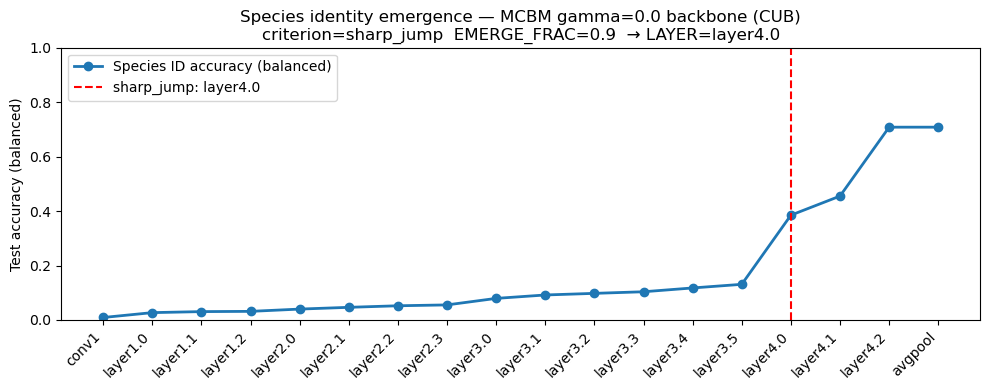

LAYER = 'layer4.0'  (used for all matched-pair analyses below)


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(species_curve, marker="o", linewidth=2,
        label=f"Species ID accuracy ({EMERGE_METRIC})")
ax.axvline(species_emerge_idx, color="red", linestyle="--", linewidth=1.5,
           label=f"{EMERGE_CRITERION}: {LAYER}")
ax.set_xticks(range(len(LAYERS)))
ax.set_xticklabels(LAYERS, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel(f"Test accuracy ({EMERGE_METRIC})")
ax.set_title(
    f"Species identity emergence — MCBM gamma=0.0 backbone (CUB)\n"
    f"criterion={EMERGE_CRITERION}  EMERGE_FRAC={EMERGE_FRAC}  → LAYER={LAYER}"
)
ax.legend()
plt.tight_layout()
plt.savefig("mcbm_cub_species_emergence_curve.png", dpi=150)
plt.show()
print(f"LAYER = {LAYER!r}  (used for all matched-pair analyses below)")

In [13]:
def align_features_and_labels(
    X_split: torch.Tensor,
    image_ids_in_feature_order: np.ndarray,
    labeled_df_split: pd.DataFrame,
):
    labeled  = labeled_df_split.set_index("image_id")[["y", "species_id", "species_name"]]
    keep_idx, rows = [], []
    for i, img_id in enumerate(image_ids_in_feature_order):
        img_id = int(img_id)
        if img_id in labeled.index:
            keep_idx.append(i)
            y, sid, sname = labeled.loc[img_id]
            rows.append((img_id, int(sid), str(sname), int(y)))
    X_aligned  = X_split[keep_idx]
    df_aligned = pd.DataFrame(rows, columns=["image_id", "species_id", "species_name", "y"])
    return X_aligned, df_aligned


def build_attr_labeled_df(
    meta: pd.DataFrame,
    img_attr_long: pd.DataFrame,
    attr_id: int,
    min_certainty: int = 1,
) -> pd.DataFrame:
    sub = img_attr_long[img_attr_long["attr_id"] == int(attr_id)].copy()
    sub = sub[sub["certainty"] >= int(min_certainty)].copy()
    # CUB has multiple annotators per (image, attribute) — collapse to one row
    sub = (sub.groupby("image_id", as_index=False)
              .agg(is_present=("is_present", "max"), certainty=("certainty", "max")))
    out = meta.merge(sub[["image_id", "is_present", "certainty"]], on="image_id", how="inner")
    out = out.rename(columns={"is_present": "y"})
    out["y"] = out["y"].astype(int)
    return out[["image_id", "species_id", "species_name", "is_train", "y", "certainty"]]


print("Defined: align_features_and_labels  build_attr_labeled_df")

Defined: align_features_and_labels  build_attr_labeled_df


In [14]:
class LinearProbe(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.lin = nn.Linear(d, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)


def train_probe(
    Xtr: torch.Tensor, ytr: np.ndarray,
    seed=0, lr=1e-2, wd=1e-4, epochs=25, batch=512,
):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    Xtr   = Xtr.to(device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device)
    probe = LinearProbe(Xtr.shape[1]).to(device)
    opt   = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)
    pos   = float(ytr_t.mean().item())
    pos_weight = (
        torch.tensor([(1 - pos) / pos], device=device)
        if 0 < pos < 1
        else torch.tensor([1.0], device=device)
    )
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    n = Xtr.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx    = perm[i:i + batch]
            logits = probe(Xtr[idx])
            loss   = loss_fn(logits, ytr_t[idx])
            opt.zero_grad(); loss.backward(); opt.step()
    return probe


@torch.no_grad()
def predict_probs(probe: nn.Module, X: torch.Tensor, batch=4096) -> np.ndarray:
    probe.eval()
    probs = []
    for i in range(0, X.shape[0], batch):
        logits = probe(X[i:i + batch].to(device))
        probs.append(torch.sigmoid(logits).detach().cpu())
    return torch.cat(probs, dim=0).numpy()


print("Defined: LinearProbe  train_probe  predict_probs")

Defined: LinearProbe  train_probe  predict_probs


In [15]:
def bootstrap_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))


def bootstrap_p_value(values, null=0.0):
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan
    return float(2.0 * min(np.mean(v <= null), np.mean(v >= null)))


print("Defined: bootstrap_ci  bootstrap_p_value")

Defined: bootstrap_ci  bootstrap_p_value


In [16]:
def eval_pair_vectorized(
    probs, y_arr, sid_arr, sid_A, sid_B,
    mpos, n_seeds, seed=0, thr=0.5,
):
    """
    Bootstrap recall-gap for one species pair — all seeds in one numpy call.
    CUB has within-species negatives, so we only resample positives (recall = TP/P).
    """
    rng   = np.random.default_rng(seed)
    A_pos = np.where((sid_arr == sid_A) & (y_arr == 1))[0]
    B_pos = np.where((sid_arr == sid_B) & (y_arr == 1))[0]
    iAp   = rng.integers(len(A_pos), size=(n_seeds, mpos))
    iBp   = rng.integers(len(B_pos), size=(n_seeds, mpos))
    pred_bin = (np.asarray(probs) >= thr).astype(np.int8)
    recA  = pred_bin[A_pos[iAp]].mean(axis=1)
    recB  = pred_bin[B_pos[iBp]].mean(axis=1)
    gaps  = np.abs(recA - recB)
    sgaps = recA - recB
    EPS   = 1e-12
    return {
        "sid_A": int(sid_A), "sid_B": int(sid_B),
        "species_A": spname(sid_A), "species_B": spname(sid_B),
        "npos": int(mpos),
        "gap_mean":  float(gaps.mean()),
        "gap_std":   float(gaps.std()),
        "gap_ci_lo": float(np.quantile(gaps, 0.025)),
        "gap_ci_hi": float(np.quantile(gaps, 0.975)),
        "gap_p":     float(2.0 * min(float(np.mean(sgaps <= 0)),
                                      float(np.mean(sgaps >= 0)))),
        "gap_snr":   float(gaps.mean() / (gaps.std() + EPS)),
        "gap_norm":  float(gaps.mean()),
        "n_runs":    n_seeds,
    }


def make_candidate_pairs(df_test: pd.DataFrame, min_each=10, max_pairs=200, seed=0):
    g    = df_test.groupby("species_id")["y"].agg(["count", "sum"]).rename(columns={"sum": "pos"})
    g["neg"] = g["count"] - g["pos"]
    ok   = g[(g["pos"] >= min_each) & (g["neg"] >= min_each)]
    sids = ok.index.to_list()
    rng  = np.random.default_rng(seed)
    pairs = []
    if len(sids) < 2:
        return pairs
    for _ in range(max_pairs * 10):
        a, b = rng.choice(sids, size=2, replace=False)
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        mneg = int(min(ok.loc[a, "neg"], ok.loc[b, "neg"]))
        if mpos >= min_each and mneg >= min_each:
            pairs.append((int(a), int(b), mpos, mneg))
        if len(pairs) >= max_pairs:
            break
    return pairs


def matched_pair_bootstrap_summary(df_te, probs, pairs, *, thr=0.5, B=300):
    if not pairs:
        return pd.DataFrame()
    y_arr   = df_te["y"].to_numpy(dtype=int)
    sid_arr = df_te["species_id"].to_numpy()
    rows = [
        eval_pair_vectorized(probs, y_arr, sid_arr, a, b, mpos,
                             n_seeds=B, seed=i, thr=thr)
        for i, (a, b, mpos, mneg) in enumerate(pairs)
    ]
    pair_summary = pd.DataFrame(rows)
    pair_summary["gap_ci_width"] = pair_summary["gap_ci_hi"] - pair_summary["gap_ci_lo"]
    return pair_summary.sort_values("gap_mean", ascending=False).reset_index(drop=True)


print("Defined: eval_pair_vectorized  make_candidate_pairs  matched_pair_bootstrap_summary")

Defined: eval_pair_vectorized  make_candidate_pairs  matched_pair_bootstrap_summary


In [17]:
def species_recall_prevalence_table(df_te, probs, thr=0.5):
    df = df_te[["species_id", "species_name", "y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)
    df["pred"] = (df["prob"] >= thr).astype(int)
    g = (
        df.groupby(["species_id", "species_name"], as_index=False)
        .agg(n=("y","size"), n_pos=("y","sum"), n_pred_pos=("pred","sum"))
    )
    g["n_neg"]      = g["n"] - g["n_pos"]
    g["prevalence"] = g["n_pos"] / g["n"]
    tp = (df[df["y"] == 1].groupby(["species_id","species_name"])["pred"]
            .sum().reset_index(name="tp"))
    out = g.merge(tp, on=["species_id","species_name"], how="left")
    out["tp"]        = out["tp"].fillna(0).astype(int)
    out["recall"]    = np.where(out["n_pos"] > 0, out["tp"] / out["n_pos"], np.nan)
    out["precision"] = np.where(out["n_pred_pos"] > 0, out["tp"] / out["n_pred_pos"], np.nan)
    return out.sort_values("n", ascending=False).reset_index(drop=True)


def add_species_bootstrap_ci(df_te, probs, thr=0.5, B=300, min_pos_for_ci=1):
    df_te = df_te.reset_index(drop=True)
    base  = species_recall_prevalence_table(df_te, probs, thr=thr)
    y_arr = df_te["y"].to_numpy(dtype=int)
    p_arr = np.asarray(probs, dtype=float)
    rng   = np.random.default_rng(0)
    ci_rows = []
    for (sid, sname), grp in df_te.groupby(["species_id","species_name"]):
        idx   = grp.index.to_numpy()
        y_s   = y_arr[idx]; p_s = p_arr[idx]; n = len(idx)
        n_pos = int(y_s.sum())
        if n_pos < min_pos_for_ci:
            ci_rows.append({"species_id": int(sid), "species_name": str(sname),
                            "recall_bs_mean": np.nan, "recall_ci_lo": np.nan,
                            "recall_ci_hi": np.nan, "recall_ci_width": np.nan, "B": B})
            continue
        boot_idx  = rng.integers(0, n, size=(B, n))
        y_boot    = y_s[boot_idx]; p_boot = p_s[boot_idx]
        pos_mask  = (y_boot == 1); pred_mask = (p_boot >= thr)
        n_pos_bt  = pos_mask.sum(axis=1); tp_bt = (pos_mask & pred_mask).sum(axis=1)
        with np.errstate(invalid="ignore"):
            recalls = np.where(n_pos_bt > 0, tp_bt / n_pos_bt, np.nan)
        lo, hi = bootstrap_ci(recalls)
        ci_rows.append({
            "species_id": int(sid), "species_name": str(sname),
            "recall_bs_mean": float(np.nanmean(recalls)),
            "recall_ci_lo": lo, "recall_ci_hi": hi,
            "recall_ci_width": (hi - lo) if np.isfinite(lo) and np.isfinite(hi) else np.nan,
            "B": B,
        })
    return base.merge(pd.DataFrame(ci_rows), on=["species_id","species_name"], how="left")


print("Defined: species_recall_prevalence_table  add_species_bootstrap_ci")

Defined: species_recall_prevalence_table  add_species_bootstrap_ci


In [18]:
def run_one_attribute(
    attr_name: str,
    feat_dir: Path,
    split_order_kind_train: str,
    split_order_train: np.ndarray,
    split_order_kind_test: str,
    split_order_test: np.ndarray,
    layer: str,
    *,
    Xtr_all: torch.Tensor = None,
    Xte_all: torch.Tensor = None,
    min_certainty: int = 1,
    thr: float = 0.5,
    epochs: int = 25,
    min_each: int = 10,
    n_pairs: int = 200,
    B_gap: int = 100,
    B_species: int = 100,
    use_balanced_acc: bool = None,
):
    _use_bal = use_balanced_acc if use_balanced_acc is not None else (EMERGE_METRIC == "balanced")
    assert (split_order_kind_train == "image_id_like" and
            split_order_kind_test  == "image_id_like"), (
        "labels_{split}.pt must contain image_ids for alignment."
    )
    if Xtr_all is None:
        Xtr_all = load_features(feat_dir, layer, "train")
    if Xte_all is None:
        Xte_all = load_features(feat_dir, layer, "test")

    aid       = attr_name_to_id[attr_name]
    lab       = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
    lab_train = lab[lab["is_train"] == 1].copy()
    lab_test  = lab[lab["is_train"] == 0].copy()

    Xtr, df_tr = align_features_and_labels(Xtr_all, split_order_train, lab_train)
    Xte, df_te = align_features_and_labels(Xte_all, split_order_test,  lab_test)
    ytr = df_tr["y"].astype(int).to_numpy()
    yte = df_te["y"].astype(int).to_numpy()

    probe = train_probe(Xtr, ytr, seed=0, epochs=epochs)
    probs = predict_probs(probe, Xte)

    species_table = (
        add_species_bootstrap_ci(df_te, probs, thr=thr, B=B_species)
        if B_species > 0
        else species_recall_prevalence_table(df_te, probs, thr=thr)
    )

    if len(yte) == 0:
        test_acc = np.nan
    elif _use_bal:
        pred_bin = (probs >= thr).astype(int)
        tp = int(((pred_bin == 1) & (yte == 1)).sum())
        tn = int(((pred_bin == 0) & (yte == 0)).sum())
        fp = int(((pred_bin == 1) & (yte == 0)).sum())
        fn = int(((pred_bin == 0) & (yte == 1)).sum())
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        test_acc = 0.5 * (tpr + tnr)
    else:
        test_acc = float(((probs >= thr).astype(int) == yte).mean())

    if n_pairs is None or int(n_pairs) <= 0:
        pairs = []; pair_summary = pd.DataFrame()
    else:
        pairs = make_candidate_pairs(df_te, min_each=min_each, max_pairs=n_pairs, seed=0)
        pair_summary = matched_pair_bootstrap_summary(df_te, probs, pairs, thr=thr, B=B_gap)

    mean_gap = float(pair_summary["gap_mean"].mean())        if len(pair_summary) else np.nan
    p90_gap  = float(pair_summary["gap_mean"].quantile(0.9)) if len(pair_summary) else np.nan

    info = {
        "attr":           attr_name,
        "layer":          layer,
        "n_train":        int(len(df_tr)),
        "n_test":         int(len(df_te)),
        "train_pos_rate": float(ytr.mean()) if len(ytr) else np.nan,
        "test_pos_rate":  float(yte.mean()) if len(yte) else np.nan,
        "test_acc":       float(test_acc),
        "test_acc_type":  "balanced" if _use_bal else "plain",
        "thr":            float(thr),
        "epochs":         int(epochs),
        "n_pairs":        int(len(pairs)),
        "B_gap":          int(B_gap),
        "B_species":      int(B_species),
        "mean_gap":       mean_gap,
        "p90_gap":        p90_gap,
    }
    return info, pd.DataFrame(), pair_summary, df_te, species_table

In [19]:
def screen_attributes(
    candidate_attrs,
    feat_dir: Path,
    kind_tr: str, ids_tr: np.ndarray,
    kind_te: str, ids_te: np.ndarray,
    layer: str,
    *,
    min_certainty: int = 1,
    thr: float = 0.5,
    min_pos_per_species: int  = 10,
    min_species_with_pos: int = 15,
    min_overall_prev: float   = 0.05,
    max_overall_prev: float   = 0.95,
    epochs: int = 8,
    max_attrs: int | None = None,
    verbose_every: int = 25,
    B_species: int = 200,
    use_balanced_acc: bool = None,
):
    _use_bal = use_balanced_acc if use_balanced_acc is not None else (EMERGE_METRIC == "balanced")
    rows, errors = [], []
    stats = {"tried": 0, "success": 0,
             "filtered_too_few_species_pos": 0,
             "filtered_prev_out_of_range":   0,
             "filtered_no_recall_vals":      0,
             "errored": 0}
    cand = list(candidate_attrs)
    if max_attrs is not None:
        cand = cand[:max_attrs]

    for i, attr in enumerate(cand):
        stats["tried"] += 1
        try:
            info, _, _, _, st = run_one_attribute(
                attr, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
                layer=layer, min_certainty=min_certainty, thr=thr,
                epochs=epochs, min_each=10, n_pairs=0, B_species=B_species,
                use_balanced_acc=_use_bal,
            )
            overall_prev  = float(st["n_pos"].sum() / st["n"].sum()) if st["n"].sum() > 0 else np.nan
            st_pos        = st[st["n_pos"] >= min_pos_per_species].copy()
            n_species_pos = int(len(st_pos))
            if n_species_pos < min_species_with_pos:
                stats["filtered_too_few_species_pos"] += 1; continue
            if not (min_overall_prev <= overall_prev <= max_overall_prev):
                stats["filtered_prev_out_of_range"] += 1; continue
            recall_vals = st_pos["recall"].dropna().to_numpy()
            if recall_vals.size == 0:
                stats["filtered_no_recall_vals"] += 1; continue
            stats["success"] += 1
            rows.append({
                "attr":           attr,
                "overall_prev":   overall_prev,
                "n_species_pos":  n_species_pos,
                "recall_std":     float(np.std(recall_vals)),
                "recall_range":   float(np.max(recall_vals) - np.min(recall_vals)),
                "recall_p90_p10": float(np.quantile(recall_vals, 0.9) - np.quantile(recall_vals, 0.1)),
                "test_acc":       float(info["test_acc"]),
                "test_acc_type":  info["test_acc_type"],
                "n_test":         int(info["n_test"]),
            })
            if verbose_every and (i + 1) % verbose_every == 0:
                print(f"[{i+1}/{len(cand)}] {attr}  "
                      f"prev={overall_prev:.3f}  n_sp={n_species_pos}  "
                      f"test_acc({info['test_acc_type']})={info['test_acc']:.3f}")
        except Exception as e:
            stats["errored"] += 1
            if len(errors) < 5: errors.append((attr, repr(e)))

    screen_df = pd.DataFrame(rows)
    print("\n--- Screening summary ---")
    print(f"  acc_type: {'balanced' if _use_bal else 'plain'}")
    for k, v in stats.items():
        print(f"  {k}: {v}")
    if errors:
        print("\nErrors (first few):")
        for a, msg in errors: print(f"  {a} -> {msg}")
    if screen_df.empty:
        print("\nNo attributes passed filters.")
        return screen_df
    return screen_df.sort_values(
        ["recall_p90_p10", "recall_range", "recall_std"], ascending=False
    ).reset_index(drop=True)

In [20]:
# Shuffle with fixed seed so max_attrs cap is random, not biased by attr_id order.
_rng_attrs = np.random.default_rng(42)
CANDIDATE_ATTRS = _rng_attrs.permutation(attr_df["attr_name"].tolist()).tolist()

screen_df = screen_attributes(
    CANDIDATE_ATTRS, MCBM_FEATS[0.0],
    mcbm_kind_tr, mcbm_ids_tr, mcbm_kind_te, mcbm_ids_te,
    layer=LAYER,
    min_certainty=1, thr=0.5,
    min_pos_per_species=10, min_species_with_pos=15,
    min_overall_prev=0.05, max_overall_prev=0.95,
    epochs=8, max_attrs=200, verbose_every=25,
)

if screen_df.empty:
    print("Loosening filters...")
    _rng_attrs2 = np.random.default_rng(42)
    CANDIDATE_ATTRS2 = _rng_attrs2.permutation(attr_df["attr_name"].tolist()).tolist()
    screen_df = screen_attributes(
        CANDIDATE_ATTRS2, MCBM_FEATS[0.0],
        mcbm_kind_tr, mcbm_ids_tr, mcbm_kind_te, mcbm_ids_te,
        layer=LAYER,
        min_certainty=1, thr=0.5,
        min_pos_per_species=5, min_species_with_pos=8,
        min_overall_prev=0.02, max_overall_prev=0.98,
        epochs=6, max_attrs=200, verbose_every=25,
    )

TOP_K = 12
SCREENED_ATTR_LIST = screen_df["attr"].head(TOP_K).tolist()
attr_to_spread = screen_df.set_index("attr")["recall_p90_p10"].to_dict()

print(f"\nSCREENED_ATTR_LIST ({len(SCREENED_ATTR_LIST)} attributes):")
for a in SCREENED_ATTR_LIST: print(f"  {a}")
screen_df.head(20)

[25/200] has_breast_pattern::striped  prev=0.118  n_sp=26  test_acc(balanced)=0.711

--- Screening summary ---
  acc_type: balanced
  tried: 200
  success: 75
  filtered_too_few_species_pos: 125
  filtered_prev_out_of_range: 0
  filtered_no_recall_vals: 0
  errored: 0

SCREENED_ATTR_LIST (12 attributes):
  has_bill_length::about_the_same_as_head
  has_wing_color::black
  has_breast_pattern::solid
  has_under_tail_color::black
  has_upper_tail_color::white
  has_upperparts_color::grey
  has_wing_pattern::striped
  has_head_pattern::capped
  has_bill_shape::cone
  has_primary_color::black
  has_under_tail_color::white
  has_throat_color::white


,attr,overall_prev,n_species_pos,recall_std,recall_range,recall_p90_p10,test_acc,test_acc_type,n_test
0,has_bill_length::about_the_same_as_head,0.365723,91,0.308007,1.000000,0.800000,0.685700,balanced,5794
1,has_wing_color::black,0.424750,115,0.289191,0.928571,0.766207,0.666287,balanced,5794
2,has_breast_pattern::solid,0.544356,154,0.278089,1.000000,0.757790,0.655580,balanced,5794
3,has_under_tail_color::black,0.312047,76,0.276194,0.961538,0.726496,0.635247,balanced,5794
4,has_upper_tail_color::white,0.125992,27,0.292769,0.900000,0.716538,0.667873,balanced,5794
5,has_upperparts_color::grey,0.295305,75,0.268912,0.909091,0.680693,0.639652,balanced,5794
6,has_wing_pattern::striped,0.224888,52,0.246942,1.000000,0.679327,0.650774,balanced,5794
7,has_head_pattern::capped,0.115292,18,0.260318,0.769231,0.662692,0.567061,balanced,5794
8,has_bill_shape::cone,0.253366,56,0.272342,1.000000,0.658333,0.686487,balanced,5794
9,has_primary_color::black,0.355540,85,0.261485,1.000000,0.654545,0.706001,balanced,5794


In [21]:
def run_many(
    attr_list, model_name, feat_dir,
    kind_tr, ids_tr, kind_te, ids_te,
    *,
    layer,
    min_certainty=1, thr=0.5, epochs=25, min_each=10,
    n_pairs=200, B_gap=100, B_species=100,
    use_balanced_acc=None,
):
    _use_bal = use_balanced_acc if use_balanced_acc is not None else (EMERGE_METRIC == "balanced")
    # Load once per (feat_dir, layer) — not once per attribute
    Xtr_all = load_features(feat_dir, layer, "train")
    Xte_all = load_features(feat_dir, layer, "test")
    print(f"  Loaded {layer}_train {tuple(Xtr_all.shape)}, "
          f"{layer}_test {tuple(Xte_all.shape)}")

    all_info, all_pair_summ, all_species = [], [], []
    for attr in attr_list:
        info, _, pair_summ, _, species_table = run_one_attribute(
            attr, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
            layer=layer,
            Xtr_all=Xtr_all, Xte_all=Xte_all,
            min_certainty=min_certainty, thr=thr,
            epochs=epochs, min_each=min_each, n_pairs=n_pairs,
            B_gap=B_gap, B_species=B_species,
            use_balanced_acc=_use_bal,
        )
        info = dict(info); info["model"] = model_name
        all_info.append(info)
        if pair_summ is not None and len(pair_summ):
            ps = pair_summ.copy(); ps["attr"] = attr; ps["model"] = model_name
            all_pair_summ.append(ps)
        st = species_table.copy(); st["attr"] = attr; st["model"] = model_name
        all_species.append(st)
        print(f"{model_name}  {attr}  "
              f"test_acc({info['test_acc_type']})={info['test_acc']:.4f}  "
              f"mean_gap={info['mean_gap']:.4f}")

    info_df    = pd.DataFrame(all_info)
    pairs_df   = pd.concat(all_pair_summ, ignore_index=True) if all_pair_summ else pd.DataFrame()
    species_df = pd.concat(all_species,   ignore_index=True) if all_species   else pd.DataFrame()
    return info_df, pairs_df, species_df

In [22]:
mcbm_results = {}   # g -> (info_df, pairs_df, species_df)

for g in GAMMAS:
    print(f"\n{'='*60}")
    print(f"  MCBM CUB  gamma={g}  (LAYER={LAYER})")
    print(f"{'='*60}")
    info, pairs, species = run_many(
        SCREENED_ATTR_LIST, f"mcbm_gamma{g}", MCBM_FEATS[g],
        mcbm_kind_tr, mcbm_ids_tr,
        mcbm_kind_te, mcbm_ids_te,
        layer=LAYER, thr=0.5, n_pairs=200, B_gap=100, B_species=100,
    )
    mcbm_results[g] = (info, pairs, species)
    print(f"  test_acc_type: {info['test_acc_type'].iloc[0]}")

print("\nDone. Results in mcbm_results[gamma].")


  MCBM CUB  gamma=0.0  (LAYER=layer4.0)
  Loaded layer4.0_train (5994, 2048), layer4.0_test (5794, 2048)
mcbm_gamma0.0  has_bill_length::about_the_same_as_head  test_acc(balanced)=0.6885  mean_gap=0.3070
mcbm_gamma0.0  has_wing_color::black  test_acc(balanced)=0.6811  mean_gap=0.3363
mcbm_gamma0.0  has_breast_pattern::solid  test_acc(balanced)=0.6642  mean_gap=0.2934
mcbm_gamma0.0  has_under_tail_color::black  test_acc(balanced)=0.6271  mean_gap=0.1737
mcbm_gamma0.0  has_upper_tail_color::white  test_acc(balanced)=0.6647  mean_gap=0.3940
mcbm_gamma0.0  has_upperparts_color::grey  test_acc(balanced)=0.6261  mean_gap=0.3088
mcbm_gamma0.0  has_wing_pattern::striped  test_acc(balanced)=0.6502  mean_gap=0.2550
mcbm_gamma0.0  has_head_pattern::capped  test_acc(balanced)=0.6248  mean_gap=0.2676
mcbm_gamma0.0  has_bill_shape::cone  test_acc(balanced)=0.7098  mean_gap=0.3088
mcbm_gamma0.0  has_primary_color::black  test_acc(balanced)=0.7126  mean_gap=0.3073
mcbm_gamma0.0  has_under_tail_color:

In [23]:
import os
os.makedirs("mcbm_cub_results", exist_ok=True)

for g in GAMMAS:
    info, pairs, species = mcbm_results[g]
    if not info.empty:    info.to_csv(f"mcbm_cub_results/info_gamma{g}.csv",    index=False)
    if not pairs.empty:   pairs.to_csv(f"mcbm_cub_results/pairs_gamma{g}.csv",  index=False)
    if not species.empty: species.to_csv(f"mcbm_cub_results/species_gamma{g}.csv", index=False)

print("Saved all results to mcbm_cub_results/")
print(f"\ngamma=0.0 species table (sorted by true positives, LAYER={LAYER}):")
_, _, sp0 = mcbm_results[0.0]
display(sp0.sort_values("tp", ascending=False).head(30))

Saved all results to mcbm_cub_results/

gamma=0.0 species table (sorted by true positives, LAYER=layer4.0):


,species_id,species_name,n,n_pos,n_pred_pos,n_neg,prevalence,tp,recall,precision,recall_bs_mean,recall_ci_lo,recall_ci_hi,recall_ci_width,B,attr,model
258,192,Downy Woodpecker,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_wing_color::black,mcbm_gamma0.0
448,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0
1917,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
517,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0
1933,10,Red winged Blackbird,30,29,30,1,0.966667,29,1.000000,0.966667,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
1838,107,Common Raven,30,29,30,1,0.966667,29,1.000000,0.966667,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
1919,30,Fish Crow,30,29,30,1,0.966667,29,1.000000,0.966667,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
1855,188,Pileated Woodpecker,30,29,29,1,0.966667,28,0.965517,0.965517,0.965754,0.890774,1.0,0.109226,100,has_primary_color::black,mcbm_gamma0.0
2270,146,Forsters Tern,30,29,29,1,0.966667,28,0.965517,0.965517,0.966026,0.892857,1.0,0.107143,100,has_throat_color::white,mcbm_gamma0.0
454,186,Cedar Waxwing,30,28,30,2,0.933333,28,1.000000,0.933333,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0


In [24]:
def summarize_by_attr(pairs_df: pd.DataFrame) -> pd.DataFrame:
    if pairs_df.empty:
        return pairs_df
    tmp = pairs_df.copy()
    tmp["_ci_above0"] = tmp["gap_ci_lo"] > 0
    tmp["_p_small"]   = tmp["gap_p"] <= 0.05
    return (
        tmp.groupby(["model", "attr"], as_index=False)
        .agg(
            gap_mean       = ("gap_mean",    "mean"),
            gap_median     = ("gap_mean",    "median"),
            gap_max        = ("gap_mean",    "max"),
            n_pairs        = ("gap_mean",    "size"),
            frac_p_small   = ("_p_small",    "mean"),
            frac_ci_above0 = ("_ci_above0",  "mean"),
            gap_snr_mean   = ("gap_snr",     "mean"),
        )
        .sort_values(["model", "gap_mean"], ascending=[True, False])
    )


def add_gap_interpretability_cols(pair_df: pd.DataFrame) -> pd.DataFrame:
    out = pair_df.copy()
    EPS = 1e-12
    if "gap_std" in out.columns:
        out["gap_snr"] = out["gap_mean"] / (out["gap_std"].replace(0, np.nan).fillna(EPS) + EPS)
    out["gap_norm"] = out["gap_mean"]
    return out


def top_pairs(pairs_df: pd.DataFrame, model: str, attr: str, k: int = 10) -> pd.DataFrame:
    sub = pairs_df[(pairs_df["model"] == model) & (pairs_df["attr"] == attr)].copy()
    if sub.empty:
        return sub
    cols = ["species_A", "species_B", "gap_mean", "gap_ci_lo", "gap_ci_hi",
            "gap_p", "gap_std", "gap_snr", "gap_norm", "npos", "n_runs"]
    cols = [c for c in cols if c in sub.columns]
    return sub.sort_values("gap_mean", ascending=False).head(k)[cols]


all_summaries = {}
for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty:
        print(f"gamma={g}: no pairs data"); continue
    s = summarize_by_attr(add_gap_interpretability_cols(pairs))
    all_summaries[g] = s
    print(f"\n{'='*55}")
    print(f"  Per-attribute summary  gamma={g}  (LAYER={LAYER})")
    print(f"{'='*55}")
    display(s)


  Per-attribute summary  gamma=0.0  (LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
8,mcbm_gamma0.0,has_upper_tail_color::white,0.393973,0.370742,0.848000,200,0.48,0.545,2.784344e+00
10,mcbm_gamma0.0,has_wing_color::black,0.336315,0.273149,0.819231,200,0.32,0.425,2.306279e+00
9,mcbm_gamma0.0,has_upperparts_color::grey,0.308829,0.254478,0.809091,200,0.26,0.360,2.059664e+00
1,mcbm_gamma0.0,has_bill_shape::cone,0.308804,0.263923,0.722000,200,0.30,0.360,2.047882e+00
4,mcbm_gamma0.0,has_primary_color::black,0.307337,0.256667,0.850000,200,0.27,0.355,2.080419e+00
0,mcbm_gamma0.0,has_bill_length::about_the_same_as_head,0.306992,0.249373,0.926667,200,0.30,0.360,2.273667e+00
2,mcbm_gamma0.0,has_breast_pattern::solid,0.293431,0.214641,0.934667,200,0.24,0.310,2.125073e+00
5,mcbm_gamma0.0,has_throat_color::white,0.277839,0.235500,0.817000,200,0.21,0.310,1.888975e+00
7,mcbm_gamma0.0,has_under_tail_color::white,0.274719,0.206571,0.757273,200,0.24,0.325,1.943308e+00
3,mcbm_gamma0.0,has_head_pattern::capped,0.267555,0.230839,0.736667,200,0.31,0.380,1.972347e+00



  Per-attribute summary  gamma=0.1  (LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
8,mcbm_gamma0.1,has_upper_tail_color::white,0.379663,0.361250,0.763000,200,0.465,0.515,2.549277
10,mcbm_gamma0.1,has_wing_color::black,0.336855,0.292136,0.843333,200,0.385,0.470,2.288569
5,mcbm_gamma0.1,has_throat_color::white,0.330301,0.281667,0.932857,200,0.340,0.445,2.324245
0,mcbm_gamma0.1,has_bill_length::about_the_same_as_head,0.320582,0.262231,0.929000,200,0.335,0.420,2.377841
4,mcbm_gamma0.1,has_primary_color::black,0.318065,0.264500,0.941000,200,0.325,0.385,2.215909
9,mcbm_gamma0.1,has_upperparts_color::grey,0.317271,0.266611,0.923333,200,0.280,0.350,2.180989
2,mcbm_gamma0.1,has_breast_pattern::solid,0.315824,0.257727,0.903000,200,0.300,0.400,2.134411
1,mcbm_gamma0.1,has_bill_shape::cone,0.254479,0.209286,0.747273,200,0.150,0.215,1.741362
7,mcbm_gamma0.1,has_under_tail_color::white,0.249608,0.189702,0.617000,200,0.230,0.310,1.846503
11,mcbm_gamma0.1,has_wing_pattern::striped,0.243839,0.177143,0.918000,200,0.190,0.225,1.933562



  Per-attribute summary  gamma=0.5  (LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
0,mcbm_gamma0.5,has_bill_length::about_the_same_as_head,0.343236,0.295000,1.000000,200,0.400,0.500,5.000000e+09
10,mcbm_gamma0.5,has_wing_color::black,0.331152,0.285000,0.872727,200,0.345,0.415,2.269710e+00
8,mcbm_gamma0.5,has_upper_tail_color::white,0.327828,0.221333,0.823000,200,0.385,0.425,2.362448e+00
9,mcbm_gamma0.5,has_upperparts_color::grey,0.318313,0.276364,0.797273,200,0.260,0.355,2.103190e+00
5,mcbm_gamma0.5,has_throat_color::white,0.307376,0.271090,0.805714,200,0.325,0.445,2.073966e+00
1,mcbm_gamma0.5,has_bill_shape::cone,0.306593,0.254231,0.716923,200,0.330,0.400,2.050362e+00
2,mcbm_gamma0.5,has_breast_pattern::solid,0.298913,0.237273,1.000000,200,0.275,0.345,2.500000e+09
4,mcbm_gamma0.5,has_primary_color::black,0.289524,0.225308,0.941000,200,0.205,0.290,2.068186e+00
11,mcbm_gamma0.5,has_wing_pattern::striped,0.288578,0.205487,0.914167,200,0.265,0.300,2.319893e+00
7,mcbm_gamma0.5,has_under_tail_color::white,0.239976,0.191000,0.619000,200,0.270,0.320,1.823179e+00



  Per-attribute summary  gamma=1.0  (LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
10,mcbm_gamma1.0,has_wing_color::black,0.356892,0.303036,0.938462,200,0.375,0.480,2.506203
8,mcbm_gamma1.0,has_upper_tail_color::white,0.336268,0.220000,0.872000,200,0.380,0.415,2.549245
2,mcbm_gamma1.0,has_breast_pattern::solid,0.318595,0.226643,0.906000,200,0.280,0.370,2.248605
0,mcbm_gamma1.0,has_bill_length::about_the_same_as_head,0.300952,0.244500,0.926667,200,0.325,0.405,2.240035
5,mcbm_gamma1.0,has_throat_color::white,0.300537,0.243429,0.823000,200,0.220,0.325,2.059375
9,mcbm_gamma1.0,has_upperparts_color::grey,0.299178,0.251538,0.851818,200,0.225,0.335,1.985823
4,mcbm_gamma1.0,has_primary_color::black,0.295628,0.231250,0.830000,200,0.270,0.340,2.028216
1,mcbm_gamma1.0,has_bill_shape::cone,0.270670,0.230000,0.662727,200,0.235,0.280,1.799632
3,mcbm_gamma1.0,has_head_pattern::capped,0.231170,0.192083,0.648571,200,0.190,0.260,1.727611
11,mcbm_gamma1.0,has_wing_pattern::striped,0.230284,0.163500,0.841667,200,0.200,0.245,1.811610


In [25]:
for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty: continue
    pairs_enr = add_gap_interpretability_cols(pairs)
    print(f"\n{'='*60}")
    print(f"  Top species pairs  gamma={g}  (LAYER={LAYER})")
    print(f"{'='*60}")
    for attr in SCREENED_ATTR_LIST:
        print(f"\n  Attribute: {attr}")
        display(top_pairs(pairs_enr, f"mcbm_gamma{g}", attr, k=5))


  Top species pairs  gamma=0.0  (LAYER=layer4.0)

  Attribute: has_bill_length::about_the_same_as_head


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
0,Western Grebe,Orchard Oriole,0.926667,0.800000,1.0,0.0,0.067659,13.696077,0.926667,15,100
1,Long tailed Jaeger,Orchard Oriole,0.924000,0.800000,1.0,0.0,0.066010,13.997858,0.924000,15,100
2,Baltimore Oriole,Western Grebe,0.922727,0.727273,1.0,0.0,0.076466,12.067097,0.922727,11,100
3,Horned Puffin,Orchard Oriole,0.850714,0.642857,1.0,0.0,0.099023,8.591052,0.850714,14,100
4,Louisiana Waterthrush,Orchard Oriole,0.843000,0.600000,1.0,0.0,0.115978,7.268592,0.843000,10,100



  Attribute: has_wing_color::black


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
200,Pigeon Guillemot,Tennessee Warbler,0.819231,0.538462,1.000000,0.0,0.111671,7.336110,0.819231,13,100
201,Savannah Sparrow,Bay breasted Warbler,0.804545,0.545455,1.000000,0.0,0.122221,6.582701,0.804545,11,100
202,Henslow Sparrow,Lazuli Bunting,0.802143,0.605357,1.000000,0.0,0.098900,8.110682,0.802143,14,100
203,Cape Glossy Starling,Henslow Sparrow,0.786429,0.533929,0.966071,0.0,0.114060,6.894865,0.786429,14,100
204,Indigo Bunting,Horned Puffin,0.759000,0.500000,1.000000,0.0,0.139352,5.446636,0.759000,10,100



  Attribute: has_breast_pattern::solid


...

,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
1800,Le Conte Sparrow,Baltimore Oriole,0.830000,0.625000,1.0000,0.0,0.096047,8.641615,0.830000,16,100
1801,Nighthawk,Le Conte Sparrow,0.787273,0.454545,1.0000,0.0,0.131250,5.998289,0.787273,11,100
1802,White crowned Sparrow,Pacific Loon,0.784000,0.500000,1.0000,0.0,0.130935,5.987699,0.784000,10,100
1803,Cape Glossy Starling,Le Conte Sparrow,0.780000,0.428571,1.0000,0.0,0.134271,5.809168,0.780000,14,100
1804,Le Conte Sparrow,Hooded Oriole,0.768125,0.592187,0.9375,0.0,0.098542,7.794891,0.768125,16,100



  Attribute: has_under_tail_color::white


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
2000,Pied Kingfisher,Chipping Sparrow,0.433333,0.166667,0.750000,0.00,0.169148,2.561856,0.433333,12,100
2001,Cactus Wren,Black and white Warbler,0.425000,0.100000,0.700000,0.02,0.152561,2.785762,0.425000,10,100
2002,Chipping Sparrow,Ring billed Gull,0.416667,0.166667,0.710417,0.00,0.147667,2.821663,0.416667,12,100
2003,Red bellied Woodpecker,Chipping Sparrow,0.415000,0.166667,0.666667,0.00,0.136920,3.030956,0.415000,12,100
2004,Chipping Sparrow,Red bellied Woodpecker,0.412500,0.166667,0.750000,0.00,0.149710,2.755320,0.412500,12,100



  Attribute: has_throat_color::white


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
2200,Florida Jay,White crowned Sparrow,0.823000,0.600000,1.000000,0.0,0.121536,6.771656,0.823000,10,100
2201,Green tailed Towhee,Chestnut sided Warbler,0.800000,0.583333,1.000000,0.0,0.111181,7.195504,0.800000,12,100
2202,Chestnut sided Warbler,Tropical Kingbird,0.796842,0.551316,0.947368,0.0,0.106576,7.476748,0.796842,19,100
2203,White eyed Vireo,Clay colored Sparrow,0.750833,0.416667,1.000000,0.0,0.143127,5.245914,0.750833,12,100
2204,European Goldfinch,Black and white Warbler,0.743571,0.500000,0.928571,0.0,0.112529,6.607826,0.743571,14,100


In [26]:
def attribute_emergence(
    attr_list, *, min_certainty=1, epochs=8, seed=0, metric=None, frac=None,
):
    """
    Computes attribute emergence indices across LAYERS using aligned_ref_tr/te
    (gamma=0.0 features, pre-loaded in Cell 9).
    metric: "balanced" | "plain" | None (reads EMERGE_METRIC)
    frac:   float | None (reads EMERGE_FRAC)
    """
    _metric = metric if metric is not None else EMERGE_METRIC
    _frac   = frac   if frac   is not None else EMERGE_FRAC

    attr_labels_tr, attr_labels_te = {}, {}
    for attr in attr_list:
        aid   = attr_name_to_id[attr]
        lab   = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
        lab_i = lab.set_index("image_id")
        missing_tr = set(aligned_tr_ids.tolist()) - set(lab_i.index.tolist())
        missing_te = set(aligned_te_ids.tolist()) - set(lab_i.index.tolist())
        assert not missing_tr, f"{attr}: {len(missing_tr)} train ids missing from attr labels"
        assert not missing_te, f"{attr}: {len(missing_te)} test ids missing from attr labels"
        attr_labels_tr[attr] = lab_i.loc[aligned_tr_ids, "y"].to_numpy(dtype=np.int32)
        attr_labels_te[attr] = lab_i.loc[aligned_te_ids, "y"].to_numpy(dtype=np.int32)

    rows = []
    for attr in attr_list:
        ytr, yte    = attr_labels_tr[attr], attr_labels_te[attr]
        ba_curve, acc_curve = [], []
        for L in LAYERS:
            ba, acc, _, _ = train_linear_probe_binary_weighted(
                aligned_ref_tr[L], ytr,
                aligned_ref_te[L], yte,
                epochs=epochs, seed=seed,
            )
            ba_curve.append(ba); acc_curve.append(acc)
        ba_arr      = np.asarray(ba_curve,  float)
        acc_arr     = np.asarray(acc_curve, float)
        _emerge_arr = ba_arr if _metric == "balanced" else acc_arr
        e_jump = sharp_rise_idx(_emerge_arr)
        e_frac = frac_of_final_idx(_emerge_arr, frac=_frac)
        rows.append({
            "attr":              attr,
            "emerge_idx_jump":   int(e_jump),
            "emerge_layer_jump": LAYERS[e_jump],
            "emerge_idx_frac":   int(e_frac),
            "emerge_layer_frac": LAYERS[e_frac],
            "final_ba":          float(ba_arr[-1]),
            "final_acc":         float(acc_arr[-1]),
            "emerge_metric":     _metric,
            "emerge_frac":       _frac,
        })
        print(f"  {attr}: frac{int(_frac*100)}={LAYERS[e_frac]}  "
              f"jump={LAYERS[e_jump]}  final_acc={acc_arr[-1]:.3f}")
    return pd.DataFrame(rows)


attr_emerge_df = attribute_emergence(SCREENED_ATTR_LIST)
print()
print(attr_emerge_df[["attr", "emerge_layer_frac", "emerge_layer_jump", "final_ba", "final_acc"]])

  has_bill_length::about_the_same_as_head: frac90=layer3.5  jump=layer4.2  final_acc=0.719
  has_wing_color::black: frac90=layer4.0  jump=layer4.0  final_acc=0.664
  has_breast_pattern::solid: frac90=layer4.0  jump=layer4.0  final_acc=0.663
  has_under_tail_color::black: frac90=layer4.0  jump=layer4.2  final_acc=0.642
  has_upper_tail_color::white: frac90=layer4.0  jump=layer4.2  final_acc=0.813
  has_upperparts_color::grey: frac90=layer3.3  jump=layer4.2  final_acc=0.719
  has_wing_pattern::striped: frac90=layer3.3  jump=layer3.0  final_acc=0.725
  has_head_pattern::capped: frac90=layer4.1  jump=layer4.2  final_acc=0.524
  has_bill_shape::cone: frac90=layer4.1  jump=layer4.2  final_acc=0.764
  has_primary_color::black: frac90=layer4.0  jump=layer4.0  final_acc=0.744
  has_under_tail_color::white: frac90=layer4.0  jump=layer4.0  final_acc=0.782
  has_throat_color::white: frac90=layer4.1  jump=layer4.2  final_acc=0.761

                                       attr emerge_layer_frac  \
0 

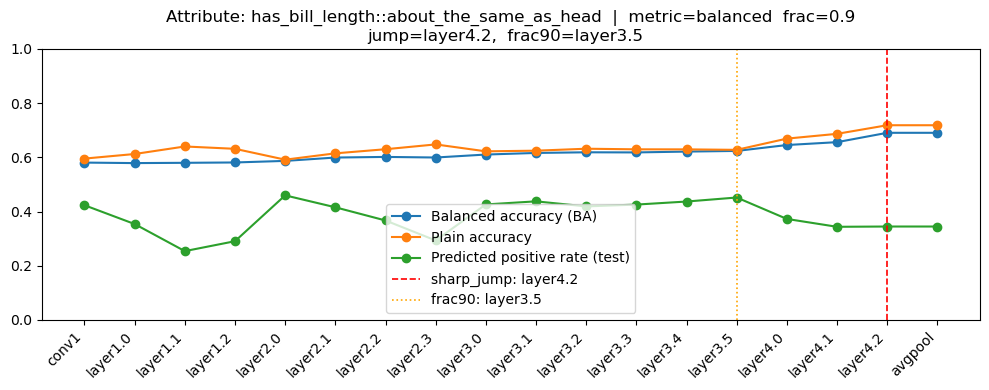

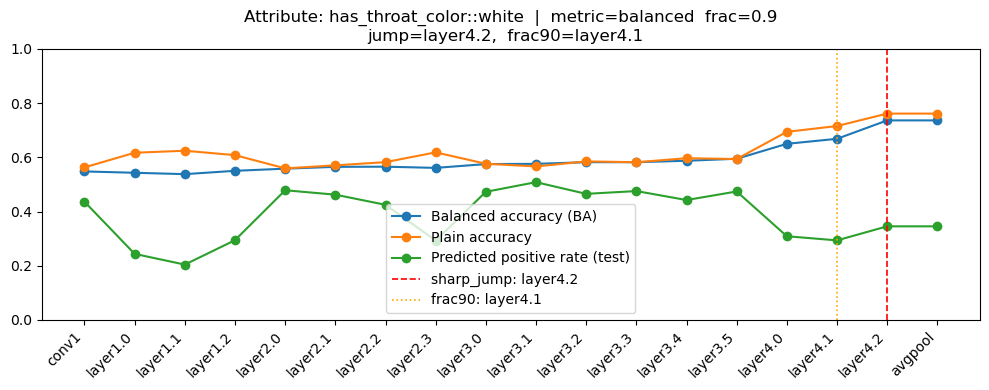

In [27]:
def plot_attribute_curve(attr: str, title_extra="", metric=None, frac=None):
    """Plots balanced acc, plain acc, and predicted positive rate across LAYERS."""
    _metric = metric if metric is not None else EMERGE_METRIC
    _frac   = frac   if frac   is not None else EMERGE_FRAC

    aid   = attr_name_to_id[attr]
    lab   = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=1)
    lab_i = lab.set_index("image_id")
    ytr   = lab_i.loc[aligned_tr_ids, "y"].to_numpy(dtype=np.int32)
    yte   = lab_i.loc[aligned_te_ids, "y"].to_numpy(dtype=np.int32)

    ba_curve, acc_curve, ppos_curve = [], [], []
    for L in LAYERS:
        ba, acc, ppos, _ = train_linear_probe_binary_weighted(
            aligned_ref_tr[L], ytr,
            aligned_ref_te[L], yte,
            epochs=8, seed=0,
        )
        ba_curve.append(ba); acc_curve.append(acc); ppos_curve.append(ppos)

    ba_arr      = np.asarray(ba_curve,  float)
    acc_arr     = np.asarray(acc_curve, float)
    _emerge_arr = ba_arr if _metric == "balanced" else acc_arr
    e_jump = sharp_rise_idx(_emerge_arr)
    e_frac = frac_of_final_idx(_emerge_arr, frac=_frac)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ba_arr,     marker="o", label="Balanced accuracy (BA)")
    ax.plot(acc_arr,    marker="o", label="Plain accuracy")
    ax.plot(ppos_curve, marker="o", label="Predicted positive rate (test)")
    ax.axvline(e_jump, color="red",    linestyle="--", linewidth=1.2,
               label=f"sharp_jump: {LAYERS[e_jump]}")
    ax.axvline(e_frac, color="orange", linestyle=":",  linewidth=1.2,
               label=f"frac{int(_frac*100)}: {LAYERS[e_frac]}")
    ax.set_xticks(range(len(LAYERS)))
    ax.set_xticklabels(LAYERS, rotation=45, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_title(
        f"Attribute: {attr}  |  metric={_metric}  frac={_frac}\n"
        f"jump={LAYERS[e_jump]},  frac{int(_frac*100)}={LAYERS[e_frac]}  {title_extra}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_attribute_curve(SCREENED_ATTR_LIST[0])
plot_attribute_curve(SCREENED_ATTR_LIST[-1])

In [28]:
print(f"EMERGE_METRIC    : {EMERGE_METRIC}")
print(f"EMERGE_FRAC      : {EMERGE_FRAC}")
print(f"EMERGE_CRITERION : {EMERGE_CRITERION}")
print(f"Species emergence layer (gamma=0.0): {LAYERS[species_emerge_idx]}")
print()

for crit, col in [("frac90", "emerge_idx_frac"), ("sharp_jump", "emerge_idx_jump")]:
    at_   = attr_emerge_df[attr_emerge_df[col] == species_emerge_idx]
    after = attr_emerge_df[attr_emerge_df[col] >  species_emerge_idx]
    pre   = attr_emerge_df[attr_emerge_df[col] <  species_emerge_idx]
    print(f"[{crit}]  PRE={len(pre)}  AT={len(at_)}  AFTER={len(after)}")

attr_emerge_df["group"] = "at"
attr_emerge_df.loc[attr_emerge_df[emerge_col] < species_emerge_idx, "group"] = "pre"
attr_emerge_df.loc[attr_emerge_df[emerge_col] > species_emerge_idx, "group"] = "post"

print(f"\nUsing criterion : {EMERGE_CRITERION}")
print("  pre: ",  (attr_emerge_df["group"] == "pre").sum(),
      "  at: ",   (attr_emerge_df["group"] == "at").sum(),
      "  post: ", (attr_emerge_df["group"] == "post").sum())
print()
print(attr_emerge_df[["attr", layer_col, "group", "final_ba", "final_acc",
                       "emerge_metric", "emerge_frac"]])

EMERGE_METRIC    : balanced
EMERGE_FRAC      : 0.9
EMERGE_CRITERION : sharp_jump
Species emergence layer (gamma=0.0): layer4.0

[frac90]  PRE=3  AT=6  AFTER=3
[sharp_jump]  PRE=1  AT=4  AFTER=7

Using criterion : sharp_jump
  pre:  1   at:  4   post:  7

                                       attr emerge_layer_jump group  final_ba  \
0   has_bill_length::about_the_same_as_head          layer4.2  post  0.690578   
1                     has_wing_color::black          layer4.0    at  0.664459   
2                 has_breast_pattern::solid          layer4.0    at  0.669479   
3               has_under_tail_color::black          layer4.2  post  0.651868   
4               has_upper_tail_color::white          layer4.2  post  0.696496   
5                has_upperparts_color::grey          layer4.2  post  0.632152   
6                 has_wing_pattern::striped          layer3.0   pre  0.648151   
7                  has_head_pattern::capped          layer4.2  post  0.638999   
8               


[gamma=0.0] Attributes by emergence group:
group
post    7
at      4
pre     1
Name: count, dtype: int64

[gamma=0.0] Mean gap by emergence group:
           mean       std  count
group                           
at     0.302951  0.025949      4
post   0.291097  0.065802      7
pre    0.255048       NaN      1


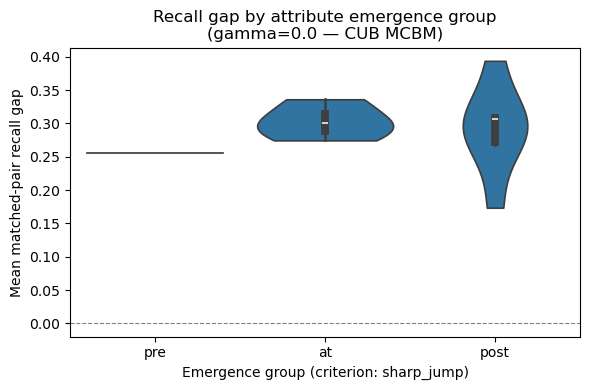


[gamma=1.0] Attributes by emergence group:
group
post    7
at      4
pre     1
Name: count, dtype: int64

[gamma=1.0] Mean gap by emergence group:
           mean       std  count
group                           
at     0.288785  0.074271      4
post   0.265291  0.072469      7
pre    0.230284       NaN      1


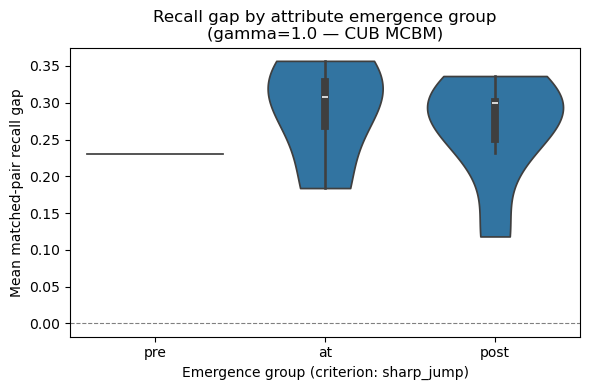

In [29]:
import os
os.makedirs("../figures", exist_ok=True)

_compare_gammas = [GAMMAS[0], GAMMAS[-1]]   # compare endpoints like funnybirds compares baseline/CBM

for g in _compare_gammas:
    info_df, pairs_df, _ = mcbm_results[g]
    if info_df.empty or "attr" not in info_df.columns:
        print(f"gamma={g}: info_df empty"); continue
    grp = info_df.merge(
        attr_emerge_df[["attr", "group", emerge_col, layer_col]],
        on="attr", how="left",
    )
    print(f"\n[gamma={g}] Attributes by emergence group:")
    print(grp["group"].value_counts())
    print(f"\n[gamma={g}] Mean gap by emergence group:")
    print(grp.groupby("group")["mean_gap"].agg(["mean", "std", "count"]))

    order = [g2 for g2 in ["pre", "at", "post"] if g2 in grp["group"].values]
    try:
        import seaborn as sns
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.violinplot(data=grp, x="group", y="mean_gap",
                       order=order, inner="box", cut=0, ax=ax)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xlabel(f"Emergence group (criterion: {EMERGE_CRITERION})")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title(f"Recall gap by attribute emergence group\n"
                     f"(gamma={g} — CUB MCBM)")
        plt.tight_layout()
        plt.savefig(f"../figures/recall_gap_by_group_mcbm_cub_gamma{g}.pdf", bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"seaborn error ({e}), using scatter fallback")
        fig, ax = plt.subplots(figsize=(6, 4))
        for g2 in order:
            vals = grp[grp["group"] == g2]["mean_gap"].dropna().values
            ax.scatter([g2] * len(vals), vals, alpha=0.6, label=g2)
        ax.axhline(0, color="grey", linestyle="--")
        ax.set_title(f"Recall gap by group (gamma={g} — CUB MCBM)")
        plt.tight_layout()
        plt.savefig(f"../figures/recall_gap_by_group_mcbm_cub_gamma{g}.pdf", bbox_inches="tight")
        plt.show()

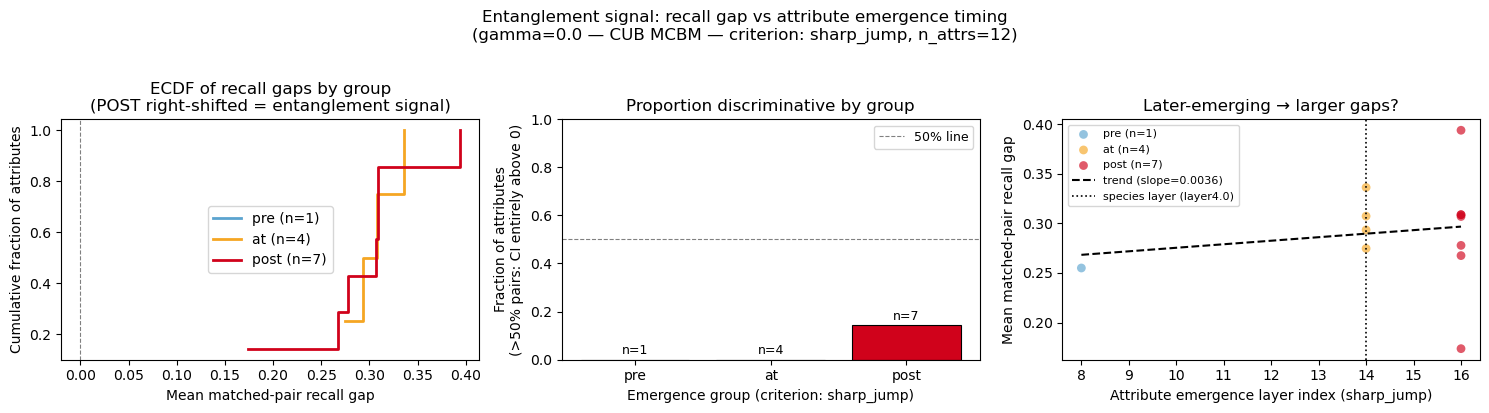

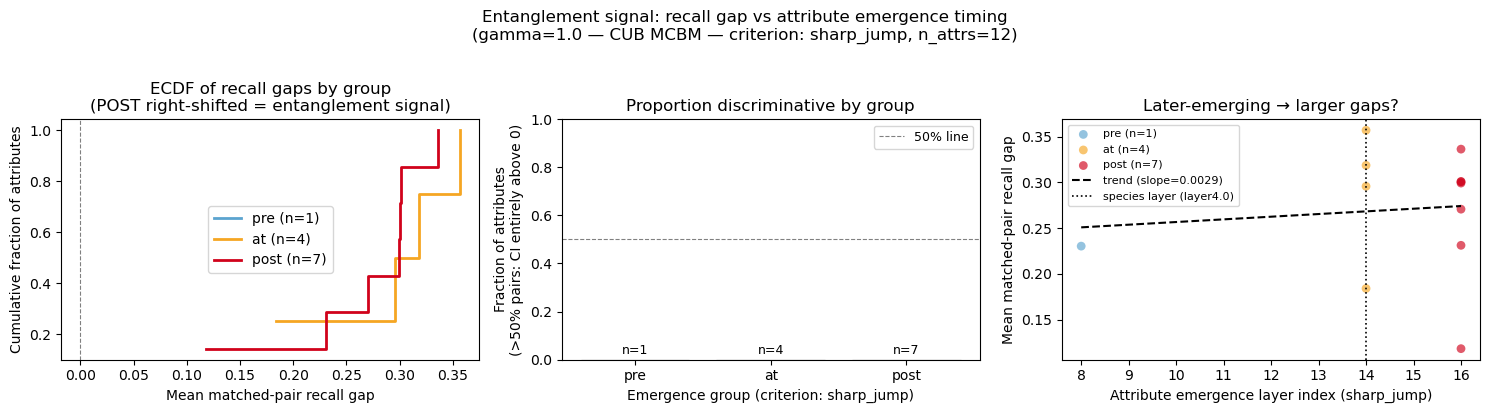

In [30]:
_egrp        = attr_emerge_df[["attr", "group", emerge_col]].drop_duplicates("attr")
group_order  = [g2 for g2 in ["pre", "at", "post"] if g2 in _egrp["group"].dropna().values]
group_colors = {"pre": "#5BA4CF", "at": "#F5A623", "post": "#D0021B"}

for g in _compare_gammas:
    info_df, pairs_df, _ = mcbm_results[g]
    summary_g = summarize_by_attr(add_gap_interpretability_cols(pairs_df)) if not pairs_df.empty else pd.DataFrame()
    if summary_g.empty:
        print(f"gamma={g}: no summary rows"); continue
    sg = summary_g.merge(_egrp, on="attr", how="left").copy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: ECDF
    ax = axes[0]
    for g2 in group_order:
        vals = sg[sg["group"] == g2]["gap_mean"].dropna().values
        if len(vals) == 0: continue
        vals_s = np.sort(vals)
        ecdf   = np.arange(1, len(vals_s) + 1) / len(vals_s)
        ax.step(vals_s, ecdf, where="post",
                label=f"{g2} (n={len(vals)})", color=group_colors.get(g2), linewidth=2)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Mean matched-pair recall gap")
    ax.set_ylabel("Cumulative fraction of attributes")
    ax.set_title("ECDF of recall gaps by group\n(POST right-shifted = entanglement signal)")
    ax.legend()

    # Plot 2: % discriminative
    ax = axes[1]
    if "frac_ci_above0" in sg.columns:
        disc_rows = []
        for g2 in group_order:
            sub = sg[sg["group"] == g2]["frac_ci_above0"].dropna()
            if len(sub) == 0: continue
            disc_rows.append({"group": g2, "frac_discriminative": float((sub > 0.5).mean()), "n": len(sub)})
        disc_df = pd.DataFrame(disc_rows)
        bars = ax.bar(disc_df["group"], disc_df["frac_discriminative"],
                      color=[group_colors.get(g2, "grey") for g2 in disc_df["group"]],
                      edgecolor="black", linewidth=0.8)
        for bar, row in zip(bars, disc_df.itertuples()):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"n={row.n}", ha="center", va="bottom", fontsize=9)
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="50% line")
        ax.set_ylim(0, 1)
        ax.set_xlabel(f"Emergence group (criterion: {EMERGE_CRITERION})")
        ax.set_ylabel("Fraction of attributes\n(>50% pairs: CI entirely above 0)")
        ax.set_title("Proportion discriminative by group")
        ax.legend(fontsize=9)

    # Plot 3: scatter — emergence index vs gap_mean
    ax = axes[2]
    if emerge_col in sg.columns:
        for g2 in group_order:
            sub = sg[sg["group"] == g2].dropna(subset=["gap_mean", emerge_col])
            if len(sub) == 0: continue
            ax.scatter(sub[emerge_col], sub["gap_mean"],
                       label=f"{g2} (n={len(sub)})",
                       color=group_colors.get(g2), alpha=0.65, s=40, edgecolors="none")
        all_v = sg.dropna(subset=["gap_mean", emerge_col])
        if len(all_v) > 5:
            xs = all_v[emerge_col].values.astype(float); ys = all_v["gap_mean"].values
            m, b = np.polyfit(xs, ys, 1)
            xline = np.linspace(xs.min(), xs.max(), 100)
            ax.plot(xline, m * xline + b, color="black", linestyle="--",
                    linewidth=1.5, label=f"trend (slope={m:.4f})")
        ax.axvline(species_emerge_idx, color="black", linestyle=":", linewidth=1.2,
                   label=f"species layer ({LAYERS[species_emerge_idx]})")
        ax.set_xlabel(f"Attribute emergence layer index ({EMERGE_CRITERION})")
        ax.set_ylabel("Mean matched-pair recall gap")
        ax.set_title("Later-emerging → larger gaps?")
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Entanglement signal: recall gap vs attribute emergence timing\n"
        f"(gamma={g} — CUB MCBM — criterion: {EMERGE_CRITERION}, n_attrs={len(sg)})",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(f"../figures/recall_gap_entanglement_mcbm_cub_gamma{g}.pdf", bbox_inches="tight")
    plt.show()

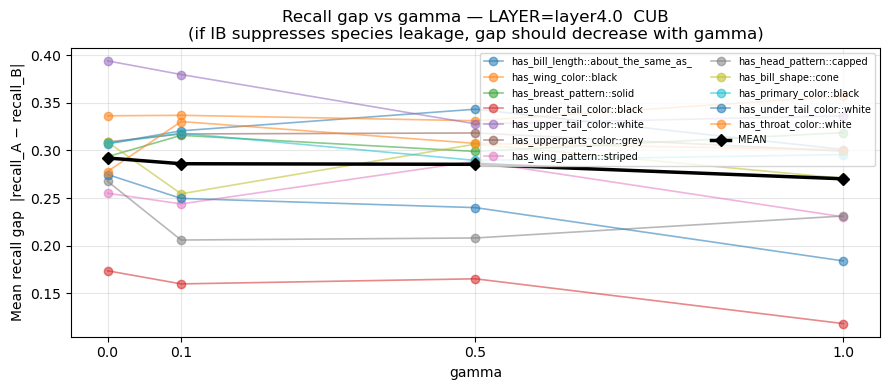

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))

gap_by_gamma = {}
for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty: continue
    for attr in SCREENED_ATTR_LIST:
        sub = pairs[pairs["attr"] == attr]
        if not sub.empty:
            gap_by_gamma.setdefault(g, {})[attr] = float(sub["gap_mean"].mean())

for attr in SCREENED_ATTR_LIST:
    ys = [gap_by_gamma.get(g, {}).get(attr, np.nan) for g in GAMMAS]
    ax.plot(GAMMAS, ys, marker="o", alpha=0.55, linewidth=1.2, label=attr[:35])

overall = [
    np.nanmean([gap_by_gamma.get(g, {}).get(a, np.nan) for a in SCREENED_ATTR_LIST])
    for g in GAMMAS
]
ax.plot(GAMMAS, overall, marker="D", color="black", linewidth=2.5, label="MEAN", zorder=5)

ax.set_xlabel("gamma")
ax.set_ylabel("Mean recall gap  |recall_A − recall_B|")
ax.set_title(f"Recall gap vs gamma — LAYER={LAYER}  CUB\n"
             "(if IB suppresses species leakage, gap should decrease with gamma)")
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.set_xticks(GAMMAS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/mcbm_cub_gap_vs_gamma.pdf", bbox_inches="tight")
plt.show()

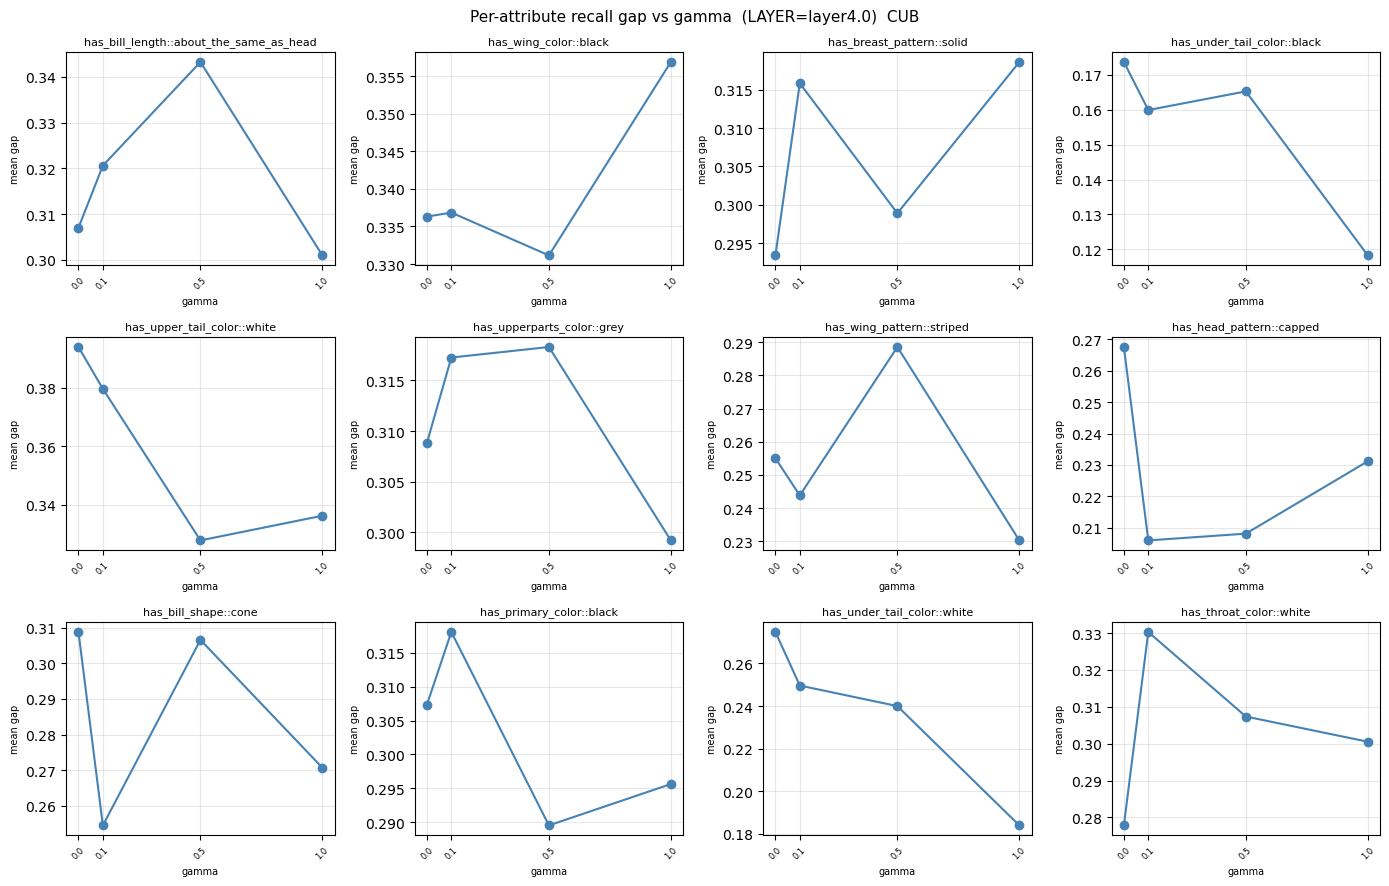

In [32]:
ncols = 4
nrows = int(np.ceil(len(SCREENED_ATTR_LIST) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for idx, attr in enumerate(SCREENED_ATTR_LIST):
    ax = axes[idx]
    ys = [gap_by_gamma.get(g, {}).get(attr, np.nan) for g in GAMMAS]
    ax.plot(GAMMAS, ys, marker="o", color="steelblue")
    ax.set_title(attr[:40], fontsize=8)
    ax.set_xlabel("gamma", fontsize=7)
    ax.set_ylabel("mean gap", fontsize=7)
    ax.set_xticks(GAMMAS)
    ax.tick_params(axis="x", labelsize=6, rotation=45)
    ax.grid(True, alpha=0.3)

for ax in axes[len(SCREENED_ATTR_LIST):]:
    ax.set_visible(False)

fig.suptitle(f"Per-attribute recall gap vs gamma  (LAYER={LAYER})  CUB", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/mcbm_cub_gap_vs_gamma_per_attr.pdf", bbox_inches="tight")
plt.show()

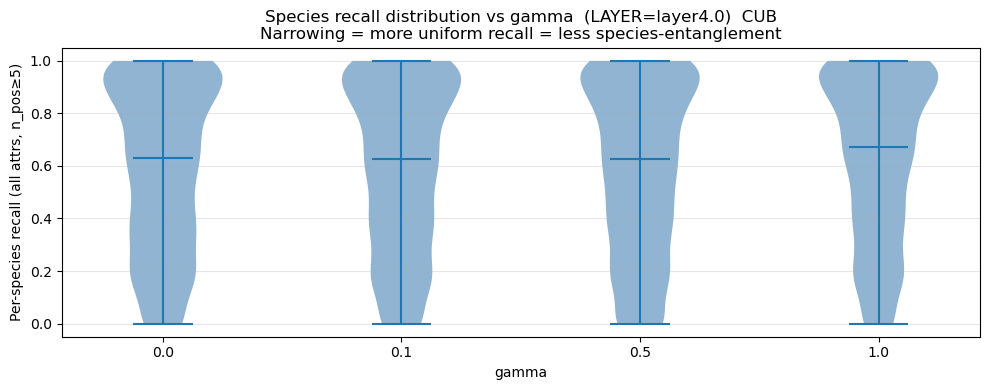

In [33]:
records = []
for g in GAMMAS:
    _, _, species = mcbm_results[g]
    if species.empty: continue
    for attr in SCREENED_ATTR_LIST:
        sub = species[(species["attr"] == attr) & (species["n_pos"] >= 5)]
        for r in sub["recall"].dropna():
            records.append({"gamma": str(g), "recall": float(r), "attr": attr})

df_violin = pd.DataFrame(records)

if not df_violin.empty:
    gamma_order = [str(g) for g in GAMMAS if str(g) in df_violin["gamma"].values]
    fig, ax = plt.subplots(figsize=(10, 4))
    parts = ax.violinplot(
        [df_violin[df_violin["gamma"] == gs]["recall"].to_numpy() for gs in gamma_order],
        positions=range(len(gamma_order)),
        showmedians=True, showextrema=True,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor("steelblue"); pc.set_alpha(0.6)
    ax.set_xticks(range(len(gamma_order)))
    ax.set_xticklabels(gamma_order)
    ax.set_xlabel("gamma")
    ax.set_ylabel("Per-species recall (all attrs, n_pos≥5)")
    ax.set_title(f"Species recall distribution vs gamma  (LAYER={LAYER})  CUB\n"
                 "Narrowing = more uniform recall = less species-entanglement")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("../figures/mcbm_cub_recall_violin_by_gamma.pdf", bbox_inches="tight")
    plt.show()

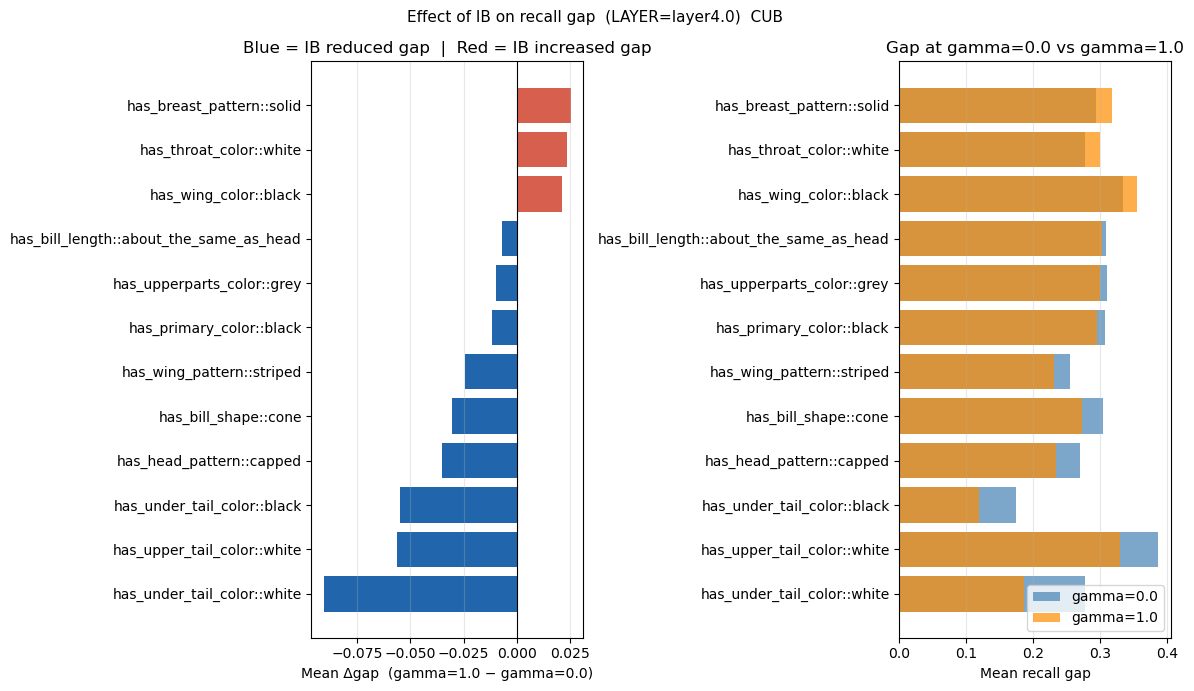

In [34]:
g_lo, g_hi = GAMMAS[0], GAMMAS[-1]
_, pairs_lo, _ = mcbm_results[g_lo]
_, pairs_hi, _ = mcbm_results[g_hi]

rows = []
for attr in SCREENED_ATTR_LIST:
    sub_lo = pairs_lo[pairs_lo["attr"] == attr] if not pairs_lo.empty else pd.DataFrame()
    sub_hi = pairs_hi[pairs_hi["attr"] == attr] if not pairs_hi.empty else pd.DataFrame()
    if sub_lo.empty or sub_hi.empty: continue
    lo_map = sub_lo.set_index(["sid_A", "sid_B"])["gap_mean"].to_dict()
    hi_map = sub_hi.set_index(["sid_A", "sid_B"])["gap_mean"].to_dict()
    keys   = set(lo_map) & set(hi_map)
    if not keys: continue
    deltas = [hi_map[k] - lo_map[k] for k in keys]
    rows.append({
        "attr":        attr[:40],
        "mean_gap_lo": float(np.mean([lo_map[k] for k in keys])),
        "mean_gap_hi": float(np.mean([hi_map[k] for k in keys])),
        "mean_delta":  float(np.mean(deltas)),
        "n_pairs":     len(deltas),
    })

df_delta = pd.DataFrame(rows).sort_values("mean_delta")

if not df_delta.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, max(3, len(df_delta) * 0.5 + 1)))
    colors = ["#2166ac" if v < 0 else "#d6604d" for v in df_delta["mean_delta"]]
    axes[0].barh(df_delta["attr"], df_delta["mean_delta"], color=colors)
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_xlabel(f"Mean Δgap  (gamma={g_hi} − gamma={g_lo})")
    axes[0].set_title("Blue = IB reduced gap  |  Red = IB increased gap")
    axes[0].grid(True, alpha=0.3, axis="x")
    axes[1].barh(df_delta["attr"], df_delta["mean_gap_lo"],
                 label=f"gamma={g_lo}", alpha=0.7, color="steelblue")
    axes[1].barh(df_delta["attr"], df_delta["mean_gap_hi"],
                 label=f"gamma={g_hi}", alpha=0.7, color="darkorange")
    axes[1].set_xlabel("Mean recall gap")
    axes[1].set_title(f"Gap at gamma={g_lo} vs gamma={g_hi}")
    axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="x")
    fig.suptitle(f"Effect of IB on recall gap  (LAYER={LAYER})  CUB", fontsize=11)
    plt.tight_layout()
    plt.savefig("../figures/mcbm_cub_gap_delta_heatmap.pdf", bbox_inches="tight")
    plt.show()

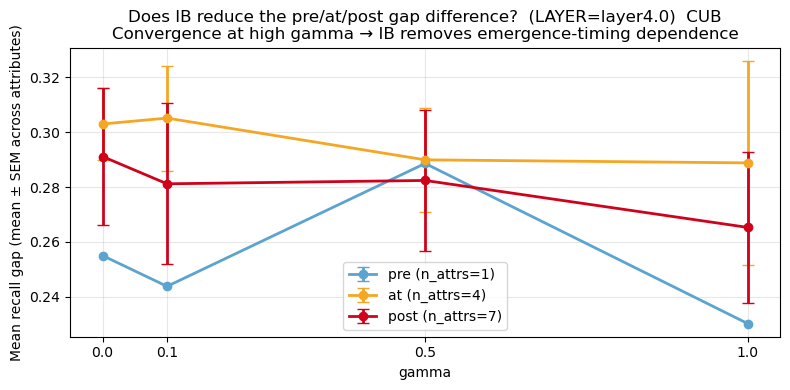

In [35]:
# Unique to MCBM: does higher gamma flatten the pre/at/post difference?
# Each line = one group (pre/at/post); x = gamma; y = mean gap for that group.
# Convergence at high gamma → IB removes the emergence-timing dependence of entanglement.

group_gamma_rows = []
for g in GAMMAS:
    info_df, _, _ = mcbm_results[g]
    if info_df.empty: continue
    grp = info_df.merge(attr_emerge_df[["attr", "group"]], on="attr", how="left")
    for gname in ["pre", "at", "post"]:
        sub = grp[grp["group"] == gname]["mean_gap"].dropna()
        if len(sub) == 0: continue
        group_gamma_rows.append({
            "gamma": g, "group": gname,
            "mean_gap": float(sub.mean()),
            "sem_gap":  float(sub.std() / np.sqrt(len(sub))),
            "n": len(sub),
        })

df_gg = pd.DataFrame(group_gamma_rows)

if not df_gg.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for gname, color in group_colors.items():
        sub = df_gg[df_gg["group"] == gname]
        if sub.empty: continue
        ax.errorbar(sub["gamma"], sub["mean_gap"], yerr=sub["sem_gap"],
                    marker="o", color=color, linewidth=2, capsize=4,
                    label=f"{gname} (n_attrs={sub['n'].iloc[0]})")
    ax.set_xlabel("gamma")
    ax.set_ylabel("Mean recall gap (mean ± SEM across attributes)")
    ax.set_title(f"Does IB reduce the pre/at/post gap difference?  (LAYER={LAYER})  CUB\n"
                 "Convergence at high gamma → IB removes emergence-timing dependence")
    ax.legend()
    ax.set_xticks(GAMMAS)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("../figures/mcbm_cub_group_gap_vs_gamma.pdf", bbox_inches="tight")
    plt.show()

In [36]:
try:
    from statsmodels.stats.multitest import multipletests
    for g in GAMMAS:
        _, pairs, _ = mcbm_results[g]
        if pairs.empty or "gap_p" not in pairs.columns:
            print(f"gamma={g}: no pairs for FDR correction"); continue
        pvals = pairs["gap_p"].fillna(1.0).to_numpy()
        reject, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
        pairs["gap_p_fdr"]   = pvals_fdr
        pairs["gap_sig_fdr"] = reject
        print(f"gamma={g}: FDR-corrected significant pairs: {int(reject.sum())} / {len(pairs)}")
    print("\nUse gap_p_fdr < 0.05 as significance threshold.")
except ImportError:
    print("statsmodels not available: pip install statsmodels")
    print("Raw p-values in gap_p column (uncorrected).")

statsmodels not available: pip install statsmodels
Raw p-values in gap_p column (uncorrected).


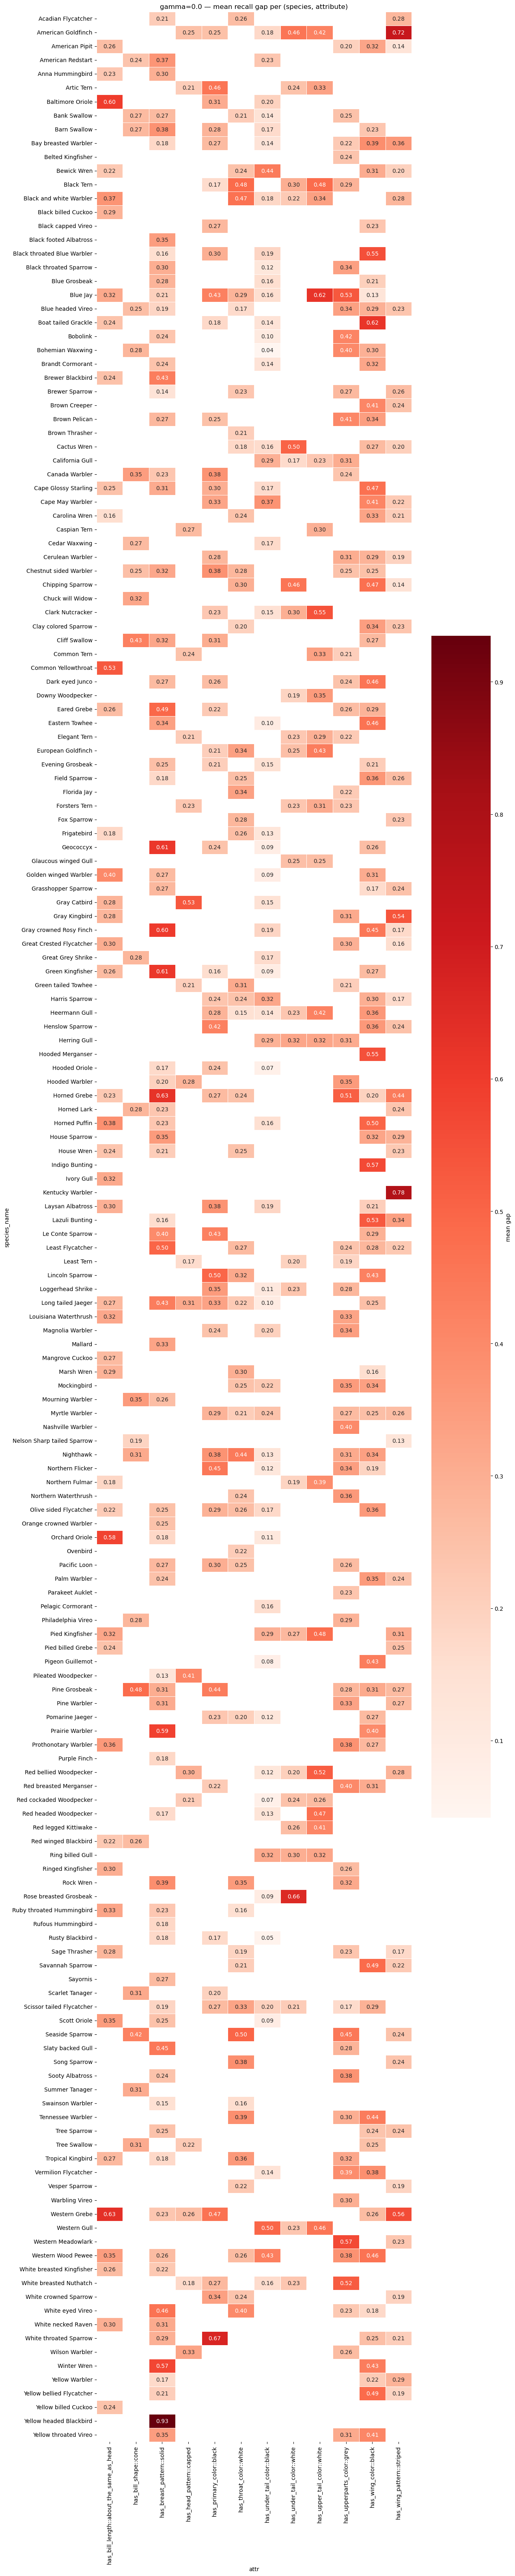

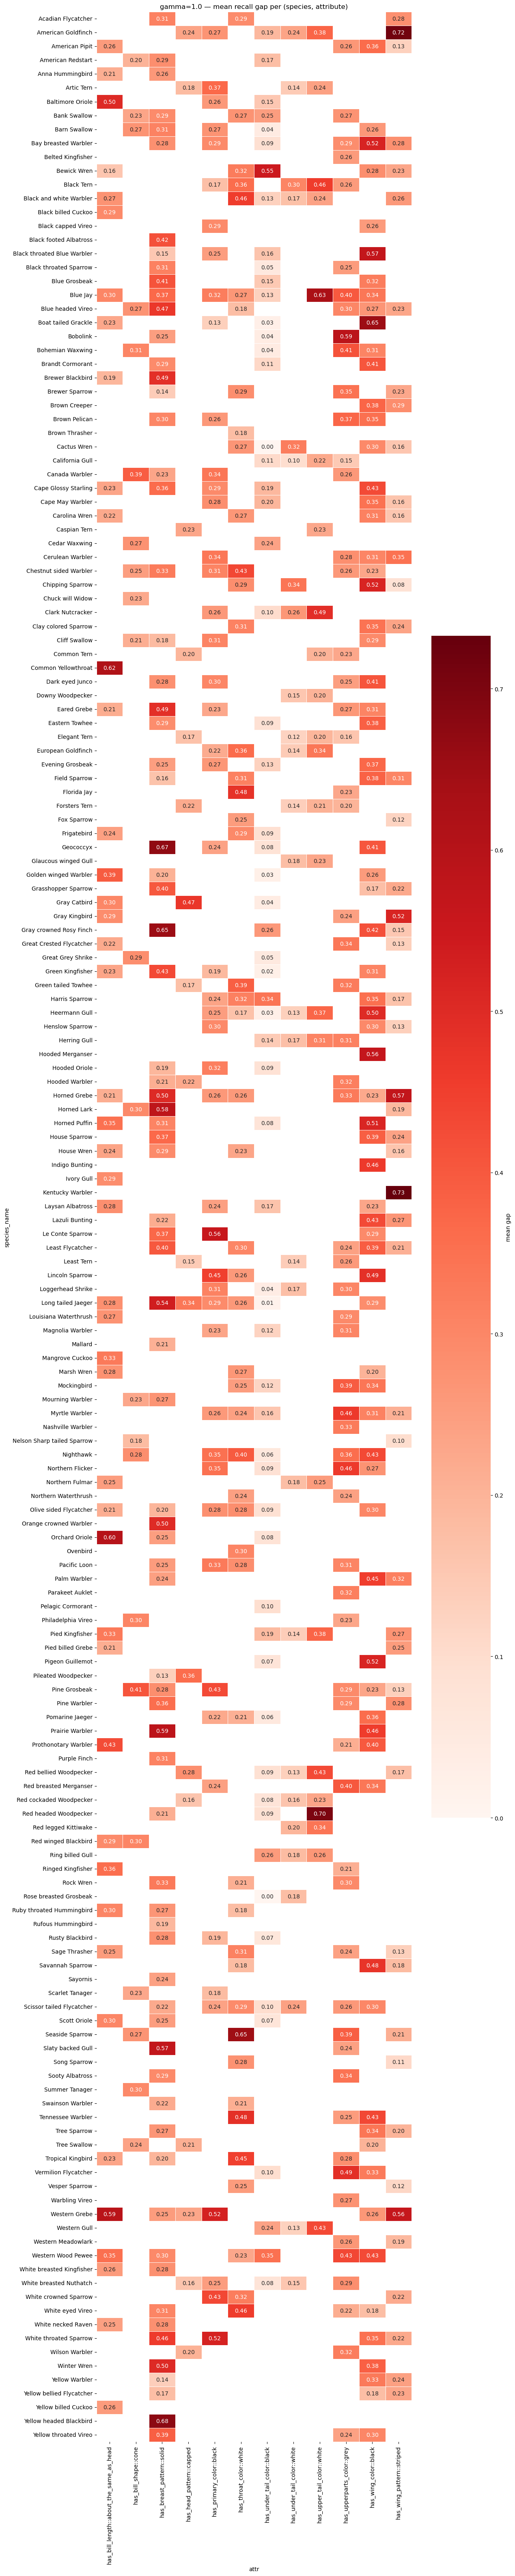

In [37]:
def species_attr_gap(pairs_df: pd.DataFrame) -> pd.DataFrame:
    if pairs_df.empty:
        return pairs_df
    a_side = pairs_df[["attr", "sid_A", "species_A", "gap_mean"]].rename(
        columns={"sid_A": "species_id", "species_A": "species_name"}
    )
    b_side = pairs_df[["attr", "sid_B", "species_B", "gap_mean"]].rename(
        columns={"sid_B": "species_id", "species_B": "species_name"}
    )
    combined = pd.concat([a_side, b_side], ignore_index=True)
    return (
        combined.groupby(["species_id", "species_name", "attr"], as_index=False)
        .agg(mean_gap=("gap_mean", "mean"), n_pairs=("gap_mean", "size"))
        .sort_values(["species_name", "mean_gap"], ascending=[True, False])
        .reset_index(drop=True)
    )


try:
    import seaborn as sns
    for g in _compare_gammas:
        _, ps, _ = mcbm_results[g]
        if ps.empty: continue
        sa    = species_attr_gap(ps)
        pivot = sa.pivot(index="species_name", columns="attr", values="mean_gap")
        fig, ax = plt.subplots(figsize=(len(pivot.columns) * 0.9 + 2, len(pivot) * 0.35 + 2))
        sns.heatmap(pivot, ax=ax, cmap="Reds", annot=True, fmt=".2f",
                    linewidths=0.4, cbar_kws={"label": "mean gap"})
        ax.set_title(f"gamma={g} — mean recall gap per (species, attribute)")
        plt.tight_layout()
        plt.show()
except ImportError:
    print("seaborn not available: pip install seaborn")

In [38]:
def species_attr_recall(species_df: pd.DataFrame, min_pos: int = 5) -> pd.DataFrame:
    df = species_df[species_df["n_pos"] >= min_pos].copy()
    attr_median = df.groupby("attr")["recall"].median().rename("attr_median_recall")
    df = df.join(attr_median, on="attr")
    df["recall_dev"] = df["recall"] - df["attr_median_recall"]
    return df[["attr", "species_name", "n_pos", "recall",
               "recall_ci_lo", "recall_ci_hi", "recall_dev", "attr_median_recall"]]


def per_species_gap(pairs_df: pd.DataFrame) -> pd.DataFrame:
    if pairs_df.empty:
        return pairs_df
    a_side = pairs_df[["sid_A", "species_A", "gap_mean"]].rename(
        columns={"sid_A": "species_id", "species_A": "species_name"}
    )
    b_side = pairs_df[["sid_B", "species_B", "gap_mean"]].rename(
        columns={"sid_B": "species_id", "species_B": "species_name"}
    )
    combined = pd.concat([a_side, b_side], ignore_index=True)
    return (
        combined.groupby(["species_id", "species_name"], as_index=False)
        .agg(mean_gap=("gap_mean", "mean"), n_pairs=("gap_mean", "size"))
        .sort_values("mean_gap", ascending=False)
        .reset_index(drop=True)
    )


def pairs_for_species(pairs_df: pd.DataFrame, species_name: str) -> pd.DataFrame:
    mask_a = pairs_df["species_A"] == species_name
    mask_b = pairs_df["species_B"] == species_name
    a_side = pairs_df[mask_a].copy(); a_side["partner"] = a_side["species_B"]
    b_side = pairs_df[mask_b].copy(); b_side["partner"] = b_side["species_A"]
    combined = pd.concat([a_side, b_side], ignore_index=True)
    cols = ["attr", "partner", "gap_mean", "gap_ci_lo", "gap_ci_hi", "gap_p", "npos", "n_runs"]
    cols = [c for c in cols if c in combined.columns]
    return combined[cols].sort_values("gap_mean", ascending=False).reset_index(drop=True)


for g in _compare_gammas:
    _, ps, sp_df = mcbm_results[g]
    if sp_df.empty: continue
    sar = species_attr_recall(sp_df)
    sp_var = (
        sar.groupby("species_name")["recall_dev"]
        .agg(recall_dev_std="std",
             recall_dev_range=lambda x: x.max() - x.min(),
             n_attrs="size")
        .sort_values("recall_dev_std", ascending=False)
        .reset_index()
    )
    print(f"\n{'='*60}")
    print(f"gamma={g} — species ranked by recall inconsistency across attrs")
    display(sp_var.head(10))

    worst = sp_var["species_name"].iloc[0]
    print(f"\ngamma={g} — worst species ({worst}): attrs driving deviation")
    display(sar[sar["species_name"] == worst].sort_values("recall_dev"))

    if not ps.empty:
        sp_rank = per_species_gap(ps)
        print(f"\ngamma={g} — top 5 species by mean gap:")
        for _, row in sp_rank.head(5).iterrows():
            sname = row["species_name"]
            print(f"\n  {sname}  (mean_gap={row['mean_gap']:.3f}, n_pairs={int(row['n_pairs'])})")
            display(pairs_for_species(ps, sname).head(8))


gamma=0.0 — species ranked by recall inconsistency across attrs


,species_name,recall_dev_std,recall_dev_range,n_attrs
0,Red legged Kittiwake,0.540770,1.504329,8
1,Louisiana Waterthrush,0.529163,1.248252,7
2,Painted Bunting,0.521909,0.946667,3
3,White Pelican,0.473331,1.175000,5
4,Ring billed Gull,0.471633,1.220147,9
5,Kentucky Warbler,0.443803,1.244048,8
6,Hooded Merganser,0.423010,1.132867,8
7,Pied billed Grebe,0.404772,1.083929,7
8,Northern Fulmar,0.404632,1.000000,9
9,Philadelphia Vireo,0.402112,1.033333,6



gamma=0.0 — worst species (Red legged Kittiwake): attrs driving deviation


,attr,species_name,n_pos,recall,recall_ci_lo,recall_ci_hi,recall_dev,attr_median_recall
787,has_under_tail_color::black,Red legged Kittiwake,5,0.000000,0.000000,0.000000,-0.853571,0.853571
387,has_wing_color::black,Red legged Kittiwake,7,0.000000,0.000000,0.000000,-0.600000,0.600000
587,has_breast_pattern::solid,Red legged Kittiwake,19,1.000000,1.000000,1.000000,0.187500,0.812500
1187,has_upperparts_color::grey,Red legged Kittiwake,14,0.500000,0.232919,0.789444,0.200000,0.300000
187,has_bill_length::about_the_same_as_head,Red legged Kittiwake,9,1.000000,1.000000,1.000000,0.275253,0.724747
2387,has_throat_color::white,Red legged Kittiwake,20,0.950000,0.872527,1.000000,0.450000,0.500000
2187,has_under_tail_color::white,Red legged Kittiwake,12,0.916667,0.682500,1.000000,0.516667,0.400000
987,has_upper_tail_color::white,Red legged Kittiwake,11,0.909091,0.773291,1.000000,0.650758,0.258333



gamma=0.0 — top 5 species by mean gap:

  Yellow headed Blackbird  (mean_gap=0.935, n_pairs=1)


...

,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,has_bill_length::about_the_same_as_head,Ringed Kingfisher,0.848,0.6000,1.0000,0.00,10,100
1,has_bill_length::about_the_same_as_head,Ringed Kingfisher,0.838,0.6000,1.0000,0.00,10,100
2,has_bill_length::about_the_same_as_head,Gray Catbird,0.815,0.5000,1.0000,0.00,10,100
3,has_bill_length::about_the_same_as_head,Horned Puffin,0.751,0.5000,1.0000,0.00,10,100
4,has_bill_length::about_the_same_as_head,Eared Grebe,0.641,0.2475,0.9000,0.00,10,100
5,has_bill_length::about_the_same_as_head,Ruby throated Hummingbird,0.562,0.2000,0.8525,0.00,10,100
6,has_bill_length::about_the_same_as_head,Gray Kingbird,0.548,0.3000,0.8525,0.00,10,100
7,has_bill_length::about_the_same_as_head,Ruby throated Hummingbird,0.539,0.2000,0.8000,0.02,10,100



  Hooded Merganser  (mean_gap=0.564, n_pairs=4)


,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,has_wing_color::black,Clay colored Sparrow,0.680000,0.406818,0.909091,0.00,11,100
1,has_wing_color::black,Carolina Wren,0.650000,0.363636,0.909091,0.00,11,100
2,has_wing_color::black,House Sparrow,0.643846,0.384615,0.923077,0.00,13,100
3,has_wing_color::black,Brown Pelican,0.282727,0.000000,0.545455,0.24,11,100



  Prairie Warbler  (mean_gap=0.504, n_pairs=11)


,attr,partner,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,npos,n_runs
0,has_breast_pattern::solid,Slaty backed Gull,0.823000,0.500000,1.000000,0.00,10,100
1,has_wing_color::black,Red breasted Merganser,0.598333,0.333333,0.877083,0.00,12,100
2,has_wing_color::black,Brown Pelican,0.593636,0.225000,0.865909,0.02,11,100
3,has_breast_pattern::solid,Palm Warbler,0.570909,0.315909,0.818182,0.00,11,100
4,has_wing_color::black,Cactus Wren,0.558462,0.267308,0.846154,0.00,13,100
5,has_wing_color::black,Brown Creeper,0.533000,0.147500,0.900000,0.00,10,100
6,has_breast_pattern::solid,Bobolink,0.527857,0.248214,0.785714,0.00,14,100
7,has_wing_color::black,Eared Grebe,0.517500,0.250000,0.833333,0.02,12,100
